In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [28]:
pd.set_option('display.max_rows', 300)

## Carregamento e filtro das categorias

In [5]:
df = pd.read_csv('./store-sales-favorita/train.csv', parse_dates=['date'])
df = df[df.date.between('2017-01-01', '2017-12-31')][['date', 'family', 'sales']]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404514 entries, 2596374 to 3000887
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    404514 non-null  datetime64[ns]
 1   family  404514 non-null  object        
 2   sales   404514 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 12.3+ MB


In [10]:
# Contando a quantidade de zeros por categoria
df.groupby('family')['sales'].apply(lambda x: (x == 0).sum())


family
AUTOMOTIVE                      506
BABY CARE                     10589
BEAUTY                         1776
BEVERAGES                       161
BOOKS                         10872
BREAD/BAKERY                    161
CELEBRATION                     416
CLEANING                        161
DAIRY                           161
DELI                            161
EGGS                            161
FROZEN FOODS                    161
GROCERY I                       161
GROCERY II                      655
HARDWARE                       4856
HOME AND KITCHEN I              170
HOME AND KITCHEN II             177
HOME APPLIANCES                8144
HOME CARE                       163
LADIESWEAR                     3817
LAWN AND GARDEN                3872
LINGERIE                       1298
LIQUOR,WINE,BEER                383
MAGAZINES                      1958
MEATS                           161
PERSONAL CARE                   161
PET SUPPLIES                   1526
PLAYERS AND ELECTRONI

In [11]:
df = df[df.family.isin(['AUTOMOTIVE', 'BEVERAGES', 'EGGS'])]
df.groupby('family').agg({'sales': 'sum'})

,sales
family,
AUTOMOTIVE,91024.0
BEVERAGES,43952592.0
EGGS,2416757.0


In [18]:
df = df[['date', 'family', 'sales']].set_index('date')

## Série não estacionária

        Data      Valor
0 2023-01-01   0.993428
1 2023-01-02   2.913641
2 2023-01-03   7.373230
3 2023-01-04  11.436230
4 2023-01-05   9.442258


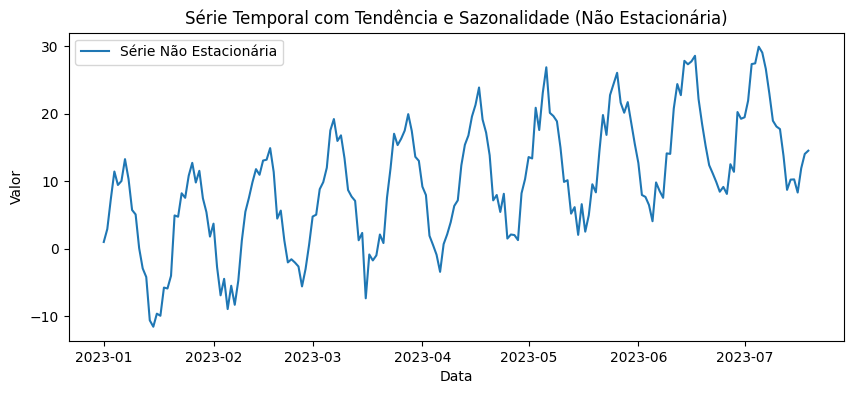

In [184]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define tamanho da série
n = 200
np.random.seed(42)

# Cria uma tendência linear e um componente aleatório
t = np.arange(n)
trend = 0.1 * t                     # tendência crescente
seasonal = 10 * np.sin(2 * np.pi * t / 20)  # componente sazonal
noise = np.random.normal(0, 2, n)   # ruído branco

# Combina tudo
serie = trend + seasonal + noise

# Coloca em um DataFrame com datas são 200 dias
datas = pd.date_range(start='2023-01-01', periods=n, freq='D')
df = pd.DataFrame({'Data': datas, 'Valor': serie})
df_trend = pd.DataFrame({'Data': datas, 'Valor': trend})
df_seasonal = pd.DataFrame({'Data': datas, 'Valor': seasonal})
df_noise = pd.DataFrame({'Data': datas, 'Valor': noise})

# Exibe e plota
print(df.head())
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal com Tendência e Sazonalidade (Não Estacionária)')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

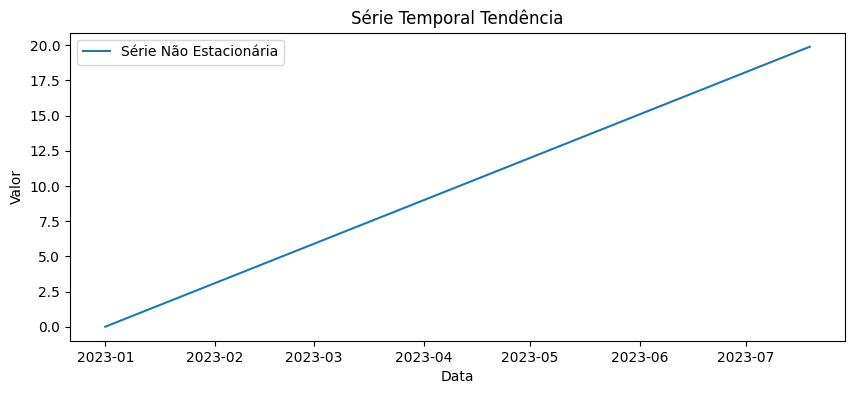

In [185]:
plt.figure(figsize=(10,4))
plt.plot(df_trend['Data'], df_trend['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal Tendência')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

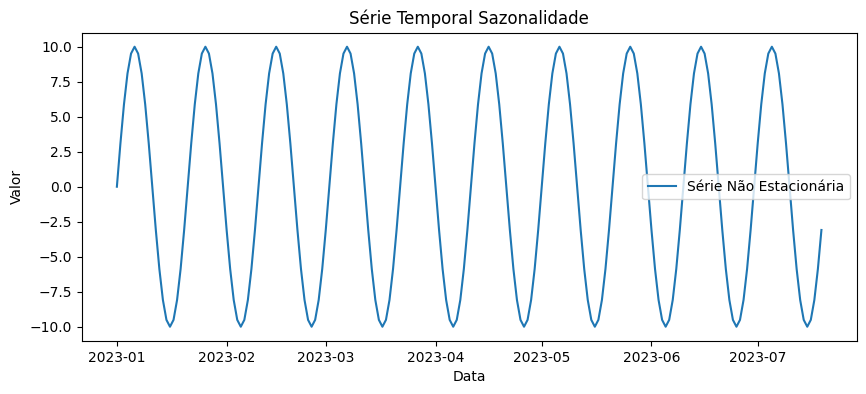

In [186]:
plt.figure(figsize=(10,4))
plt.plot(df_seasonal['Data'], df_seasonal['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal Sazonalidade')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

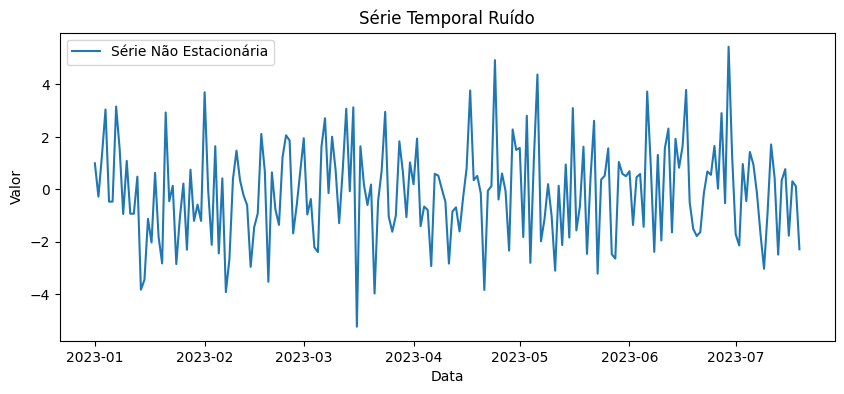

In [187]:
plt.figure(figsize=(10,4))
plt.plot(df_noise['Data'], df_noise['Valor'], label='Série Não Estacionária')
plt.title('Série Temporal Ruído')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

## Testando estacionaridade

In [119]:
from statsmodels.tsa.stattools import adfuller, kpss

In [120]:
res_ad = adfuller(df[['Valor']])
res_kp = kpss(df[['Valor']]) # kpss sempre apresentando warning, olhar isso com outro conjunto de dados

In [121]:
# p-value < 0.05 portanto hipótese nula rejeitada, série estacionária
res_ad

(np.float64(-0.7301109301072168),
 np.float64(0.8387952213851444),
 15,
 184,
 {'1%': np.float64(-3.466398230774071),
  '5%': np.float64(-2.8773796387256514),
  '10%': np.float64(-2.575213838610586)},
 np.float64(820.3990601167642))

In [122]:
res_kp

(np.float64(1.1766480346462718),
 np.float64(0.01),
 9,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [123]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

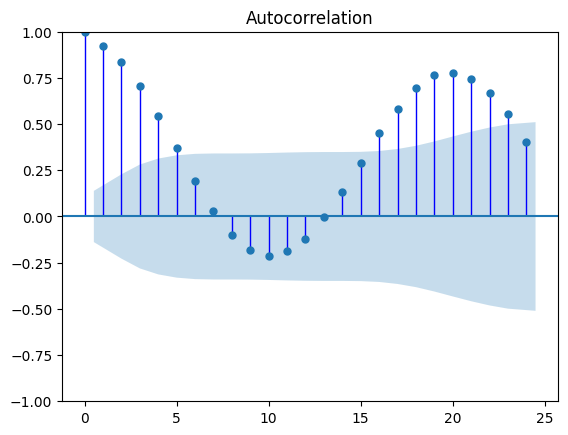

In [124]:
plot_acf(df[['Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1});

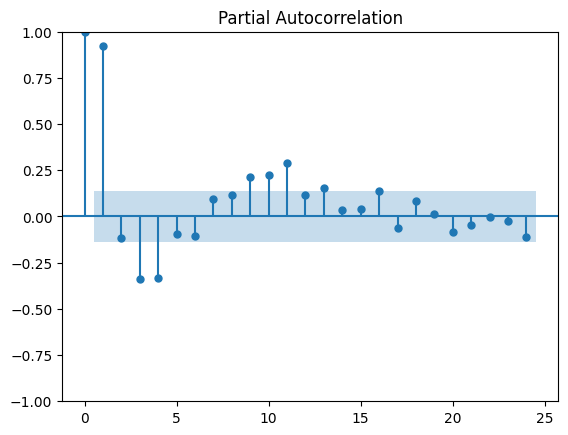

In [54]:
plot_pacf(df[['Valor']]);

## Alguns ajustes que podem ser feitos na base para deixá-la estacionária

https://medium.com/code-applied/time-series-analysis-and-forecasting-a-comparison-of-stationary-and-non-stationary-time-series-7067c0dc7e08

Essas transformações (log, Box-Cox, Yeo-Johnson etc.) servem apenas para estabilizar a variância — isto é, reduzir heterocedasticidade (quando a variabilidade cresce ou diminui com o tempo).

Elas não corrigem tendências ou sazonalidades.

Então, mesmo após a transformação, a série pode continuar não estacionária.

### Diff

In [125]:

df['diff_Valor'] = df['Valor'].diff().fillna(0)
df.head(15)

,Data,Valor,diff_Valor
0,2023-01-01,0.993428,0.000000
1,2023-01-02,2.913641,1.920213
2,2023-01-03,7.373230,4.459588
3,2023-01-04,11.436230,4.063000
4,2023-01-05,9.442258,-1.993971
5,2023-01-06,10.031726,0.589468
6,2023-01-07,13.268991,3.237265
7,2023-01-08,10.325039,-2.943951
8,2023-01-09,5.738904,-4.586136
9,2023-01-10,5.075290,-0.663614


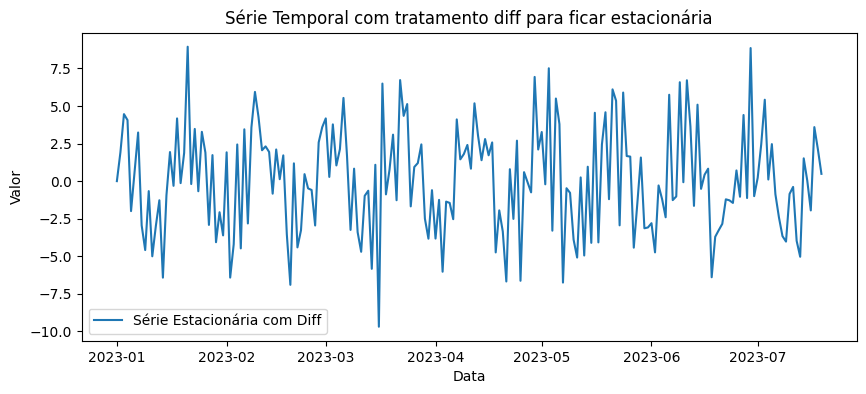

In [126]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['diff_Valor'], label='Série Estacionária com Diff')
plt.title('Série Temporal com tratamento diff para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [127]:
def stat_test(df, column):
    print(f"ADFULLER: {adfuller(df[[column]])}")
    print(f"KPSS: {kpss(df[[column]])}")

stat_test(df, 'diff_Valor')

ADFULLER: (np.float64(-9.505643216747002), np.float64(3.353122323117064e-16), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(818.214358081409))
KPSS: (np.float64(0.013192767999009867), np.float64(0.1), 7, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


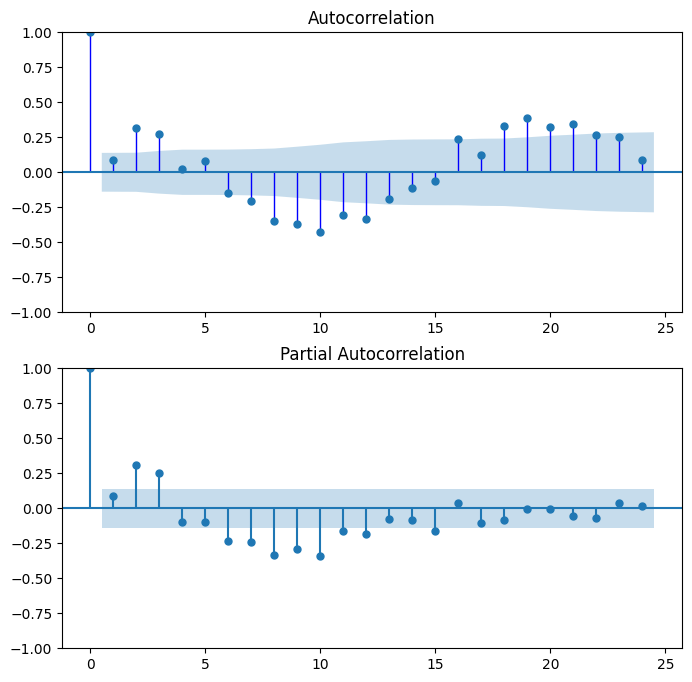

In [128]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['diff_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['diff_Valor']], ax=ax[1]);

### Log

In [129]:
# Para log todos os valores devem ser positivos
df['log_Valor'] = np.log(np.abs(df['Valor'])).fillna(0)
df.head(15)

,Data,Valor,diff_Valor,log_Valor
0,2023-01-01,0.993428,0.000000,-0.006593
1,2023-01-02,2.913641,1.920213,1.069404
2,2023-01-03,7.373230,4.459588,1.997856
3,2023-01-04,11.436230,4.063000,2.436786
4,2023-01-05,9.442258,-1.993971,2.245195
5,2023-01-06,10.031726,0.589468,2.305753
6,2023-01-07,13.268991,3.237265,2.585430
7,2023-01-08,10.325039,-2.943951,2.334572
8,2023-01-09,5.738904,-4.586136,1.747268
9,2023-01-10,5.075290,-0.663614,1.624384


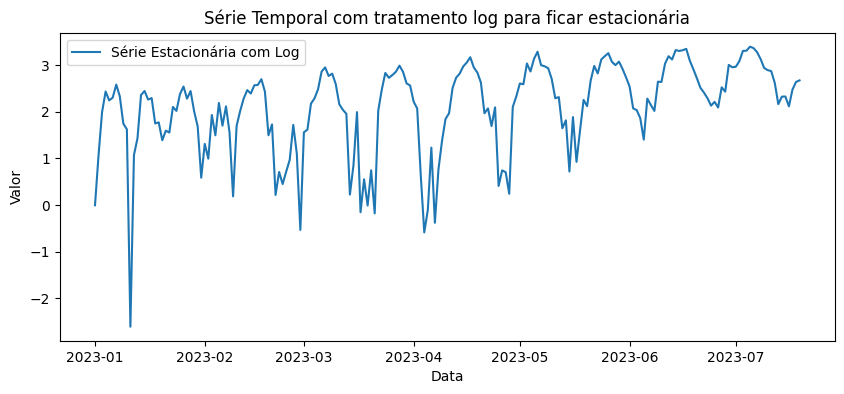

In [130]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['log_Valor'], label='Série Estacionária com Log')
plt.title('Série Temporal com tratamento log para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [131]:
stat_test(df, 'log_Valor')

ADFULLER: (np.float64(-5.1827506149794855), np.float64(9.53371720503937e-06), 4, 195, {'1%': np.float64(-3.464337030867007), '5%': np.float64(-2.876478799035722), '10%': np.float64(-2.574733103221565)}, np.float64(302.04485062498816))
KPSS: (np.float64(0.9607107953520188), np.float64(0.01), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


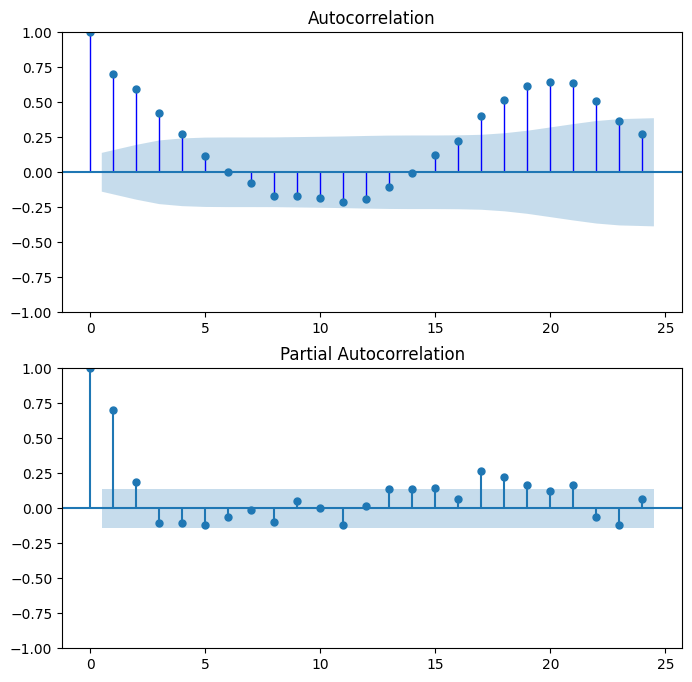

In [132]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['log_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['log_Valor']], ax=ax[1]);

### BoxCox

In [133]:
# Box-Cox exige todos os números positivos
from sklearn.preprocessing import PowerTransformer as pt
from scipy.stats import boxcox
df['boxcox_Valor'], _ = boxcox(np.abs(df['Valor']))
df['skl_boxcox_Valor'] = pt(method='box-cox').fit_transform(np.abs(df[['Valor']]))
df.head(15)

,Data,Valor,diff_Valor,log_Valor,boxcox_Valor,skl_boxcox_Valor
0,2023-01-01,0.993428,0.000000,-0.006593,-0.006582,-1.809985
1,2023-01-02,2.913641,1.920213,1.069404,1.420215,-1.214803
2,2023-01-03,7.373230,4.459588,1.997856,3.461524,-0.363280
3,2023-01-04,11.436230,4.063000,2.436786,4.817248,0.202254
4,2023-01-05,9.442258,-1.993971,2.245195,4.188190,-0.060155
5,2023-01-06,10.031726,0.589468,2.305753,4.380448,0.020045
6,2023-01-07,13.268991,3.237265,2.585430,5.349234,0.424170
7,2023-01-08,10.325039,-2.943951,2.334572,4.474040,0.059086
8,2023-01-09,5.738904,-4.586136,1.747268,2.812715,-0.633928
9,2023-01-10,5.075290,-0.663614,1.624384,2.523474,-0.754584


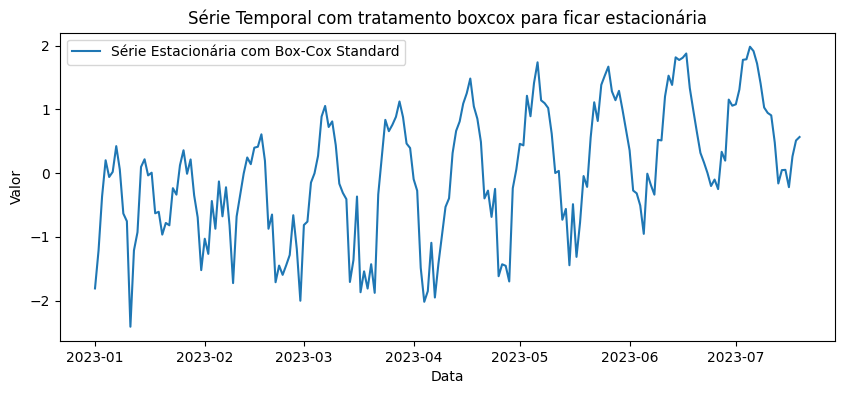

In [135]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['skl_boxcox_Valor'], label='Série Estacionária com Box-Cox Standard')
plt.title('Série Temporal com tratamento boxcox para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

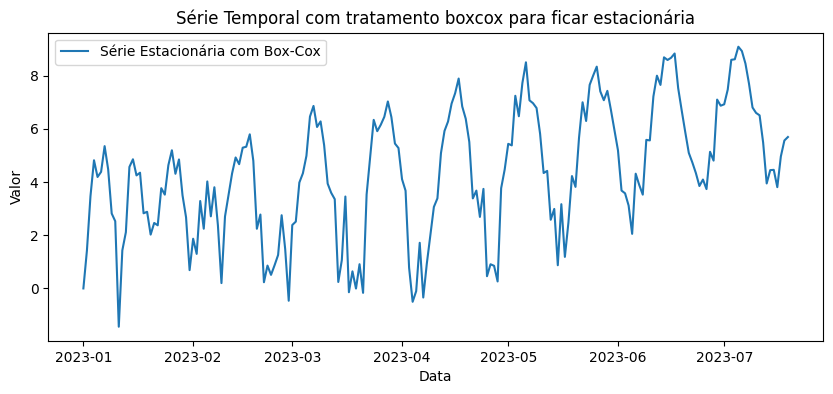

In [136]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['boxcox_Valor'], label='Série Estacionária com Box-Cox')
plt.title('Série Temporal com tratamento boxcox para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [139]:
# Com box-cox a série não virou estacionária
stat_test(df, 'skl_boxcox_Valor')
print()
stat_test(df, 'boxcox_Valor')

ADFULLER: (np.float64(-0.8522008578544666), np.float64(0.8033057689888589), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(225.5291346721699))
KPSS: (np.float64(1.0208801773204004), np.float64(0.01), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

ADFULLER: (np.float64(-0.8522008578544683), np.float64(0.8033057689888583), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(547.2789676096218))
KPSS: (np.float64(1.0208801773203997), np.float64(0.01), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


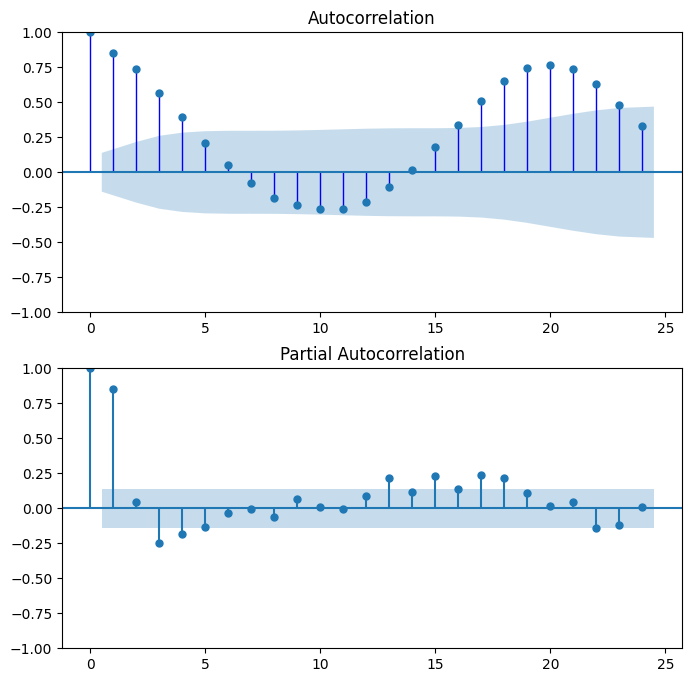

In [102]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['boxcox_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['boxcox_Valor']], ax=ax[1]);

### Yeo-Jhonson

In [140]:
from scipy.stats import yeojohnson
df['yeo_Valor'], _ = yeojohnson(df['Valor'])
df['skl_yeo_Valor'] = pt(method='yeo-johnson').fit_transform(df[['Valor']])
df.head(15)

,Data,Valor,diff_Valor,log_Valor,boxcox_Valor,skl_boxcox_Valor,yeo_Valor,skl_yeo_Valor
0,2023-01-01,0.993428,0.000000,-0.006593,-0.006582,-1.809985,0.990238,-0.965974
1,2023-01-02,2.913641,1.920213,1.069404,1.420215,-1.214803,2.893410,-0.754611
2,2023-01-03,7.373230,4.459588,1.997856,3.461524,-0.363280,7.286571,-0.266715
3,2023-01-04,11.436230,4.063000,2.436786,4.817248,0.202254,11.270880,0.175776
4,2023-01-05,9.442258,-1.993971,2.245195,4.188190,-0.060155,9.317164,-0.041201
5,2023-01-06,10.031726,0.589468,2.305753,4.380448,0.020045,9.895032,0.022976
6,2023-01-07,13.268991,3.237265,2.585430,5.349234,0.424170,13.064309,0.374951
7,2023-01-08,10.325039,-2.943951,2.334572,4.474040,0.059086,10.182476,0.054899
8,2023-01-09,5.738904,-4.586136,1.747268,2.812715,-0.633928,5.679661,-0.445175
9,2023-01-10,5.075290,-0.663614,1.624384,2.523474,-0.754584,5.026286,-0.517738


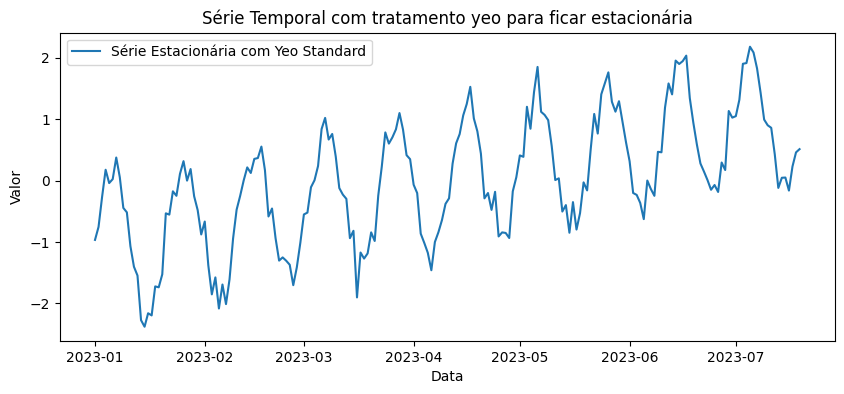

In [141]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['skl_yeo_Valor'], label='Série Estacionária com Yeo Standard')
plt.title('Série Temporal com tratamento yeo para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

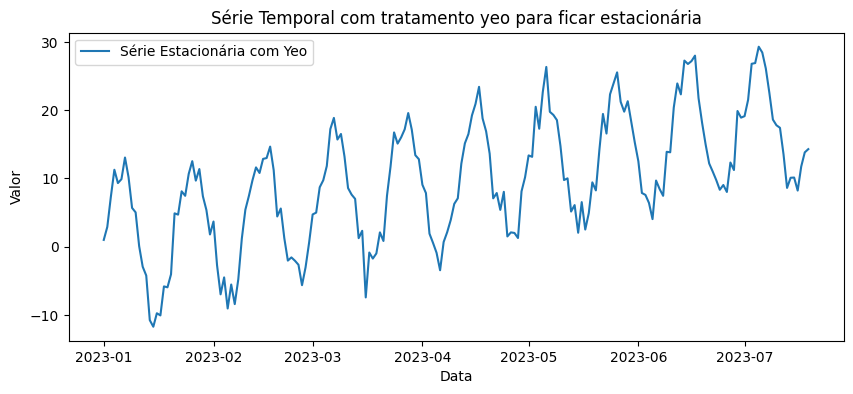

In [142]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['yeo_Valor'], label='Série Estacionária com Yeo')
plt.title('Série Temporal com tratamento yeo para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [144]:
# Yeo também não foi capaz de deixar a série estacionária
stat_test(df, 'skl_yeo_Valor')
print()
stat_test(df, 'yeo_Valor')

ADFULLER: (np.float64(-0.7737093131789236), np.float64(0.8267230502420251), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(6.883562344203767))
KPSS: (np.float64(1.176839213177776), np.float64(0.01), 9, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

ADFULLER: (np.float64(-0.7737093381335228), np.float64(0.8267230431425617), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(815.6375139207255))
KPSS: (np.float64(1.1768392132656007), np.float64(0.01), 9, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


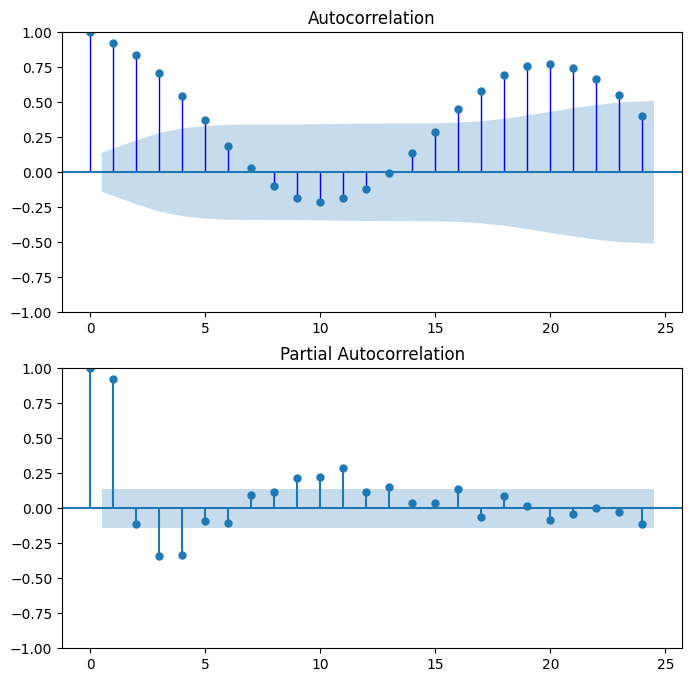

In [145]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['yeo_Valor']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['yeo_Valor']], ax=ax[1]);

### Testando transformações do box-cox e yeo-johnson

In [149]:
dft = df[['Data', 'Valor']]
dft['scp_box'], _ = boxcox(np.abs(df['Valor']))
dft['skl_box'] = pt(method='box-cox', standardize=False).fit_transform(np.abs(df[['Valor']]))
dft['skl_std_box'] = pt(method='box-cox', standardize=True).fit_transform(np.abs(df[['Valor']]))
dft['scp_yeo'], _ = yeojohnson(df['Valor'])
dft['skl_yeo'] = pt(method='yeo-johnson', standardize=False).fit_transform(df[['Valor']])
dft['skl_std_yeo'] = pt(method='yeo-johnson', standardize=True).fit_transform(df[['Valor']])
dft.head(15)

,Data,Valor,scp_box,skl_box,skl_std_box,scp_yeo,skl_yeo,skl_std_yeo
0,2023-01-01,0.993428,-0.006582,-0.006582,-1.809985,0.990238,0.990238,-0.965974
1,2023-01-02,2.913641,1.420215,1.420215,-1.214803,2.893410,2.893410,-0.754611
2,2023-01-03,7.373230,3.461524,3.461524,-0.363280,7.286571,7.286572,-0.266715
3,2023-01-04,11.436230,4.817248,4.817248,0.202254,11.270880,11.270880,0.175776
4,2023-01-05,9.442258,4.188190,4.188190,-0.060155,9.317164,9.317164,-0.041201
5,2023-01-06,10.031726,4.380448,4.380448,0.020045,9.895032,9.895032,0.022976
6,2023-01-07,13.268991,5.349234,5.349234,0.424170,13.064309,13.064309,0.374951
7,2023-01-08,10.325039,4.474040,4.474040,0.059086,10.182476,10.182477,0.054899
8,2023-01-09,5.738904,2.812715,2.812715,-0.633928,5.679661,5.679661,-0.445175
9,2023-01-10,5.075290,2.523474,2.523474,-0.754584,5.026286,5.026286,-0.517738


### Decomposição

In [158]:
def determinar_periodo(serie_original, max_periodo=12, periodo=None):
    """
    Determina automaticamente o período sazonal
    """
    if periodo is not None:
        return periodo
        
    n = len(serie_original)
    # Usa autocorrelação para determinar período
    from statsmodels.tsa.stattools import acf
    
    autocorr = acf(serie_original, nlags=min(max_periodo, n//2))
    print(autocorr)
    # Encontra o primeiro pico significativo após o lag 0
    picos = []
    for i in range(2, len(autocorr)-1):
        if autocorr[i] > autocorr[i-1] and autocorr[i] > autocorr[i+1] and autocorr[i] > 0.1:
            picos.append(i)
    
    if picos:
        periodo = picos[0]
        print(f"Período sazonal detectado: {periodo}")
    else:
        periodo = 12  # padrão para dados mensais
        print(f"Período não detectado, usando padrão: {periodo}")
        
    return periodo

periodo = determinar_periodo(df[['Valor']])

[ 1.          0.92444329  0.83762387  0.70815294  0.5426368   0.37186169
  0.19001831  0.03216404 -0.09902743 -0.18357467 -0.21507941 -0.18767998
 -0.11928887]
Período não detectado, usando padrão: 12


In [165]:
from statsmodels.tsa.seasonal import seasonal_decompose

def decompor_serie(serie_original, modelo='additive'):
    """
    Decompõe a série em tendência, sazonalidade e resíduo
    """
    # Determina período se não fornecido
    periodo = 12
    
    # Garante que a série tem comprimento suficiente
    n = len(serie_original)
    if n < 2 * periodo:
        print(f"Aviso: Série muito curta para período {periodo}. Reduzindo período.")
        periodo = max(2, n // 2)
    
    
    # Cria índice temporal para statsmodels
    if isinstance(serie_original, pd.Series):
        serie_temp = serie_original
    else:
        serie_temp = pd.Series(serie_original)
    
    # Decomposição
    decomposicao = seasonal_decompose(serie_temp, model=modelo, period=periodo)
    
    tendencia = decomposicao.trend
    sazonalidade = decomposicao.seasonal
    residuo = decomposicao.resid
    
    print("✅ Decomposição realizada com sucesso!")
    
    return tendencia, sazonalidade, residuo
    
decomp = decompor_serie(df['Valor'])

✅ Decomposição realizada com sucesso!


In [ ]:
def tornar_estacionaria(serie_original, decomp, metodo='residual'):
    """
    Torna a série estacionária usando diferentes métodos
    
    Args:
        metodo: str, método para estacionarização
        'residual' - usa apenas o resíduo
        'deseasonalized' - remove sazonalidade
        'detrended' - remove tendência
    """
    if metodo == 'residual':
        # self.serie_estacionaria = self.residuo
        serie_estacionaria = decomp[2]
        print("Método: Resíduo da decomposição")
        
    elif metodo == 'deseasonalized':
        # self.serie_estacionaria = self.serie_original - self.sazonalidade
        serie_estacionaria = serie_original - decomp[1]
        print("Método: Série dessazonalizada")
        
    elif metodo == 'detrended':
        # self.serie_estacionaria = self.serie_original - self.tendencia
        serie_estacionaria = serie_original - decomp[0]
        print("Método: Série sem tendência")
    
    return serie_estacionaria

df['decomp_residuo'] = tornar_estacionaria(df['Valor'], decomp, metodo='residual').fillna(0)
df['decomp_sazonalidade'] = tornar_estacionaria(df['Valor'], decomp, metodo='deseasonalized').fillna(0)
df['decomp_tendencia'] = tornar_estacionaria(df['Valor'], decomp, metodo='detrended').fillna(0)

Método: Resíduo da decomposição
Método: Série dessazonalizada
Método: Série sem tendência


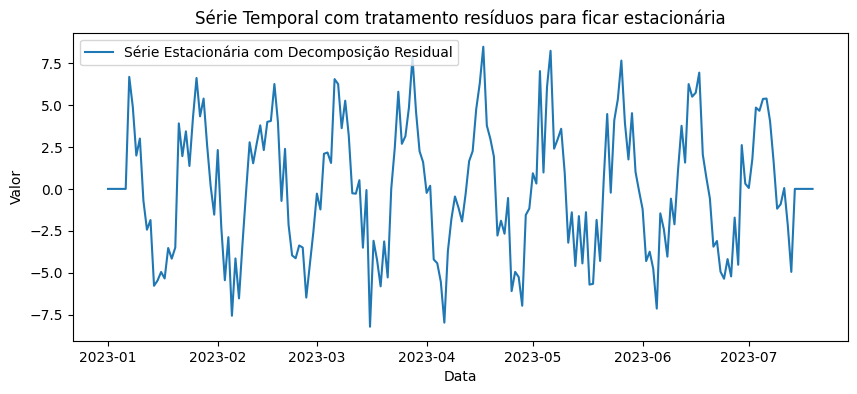

In [174]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['decomp_residuo'], label='Série Estacionária com Decomposição Residual')
plt.title('Série Temporal com tratamento resíduos para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
stat_test(df, 'decomp_residuo')

ADFULLER: (np.float64(-8.357135591502864), np.float64(2.888778899326741e-13), 13, 186, {'1%': np.float64(-3.466005071659723), '5%': np.float64(-2.8772078537639385), '10%': np.float64(-2.5751221620996647)}, np.float64(768.2005556249242))
KPSS: (np.float64(0.013241128556269752), np.float64(0.1), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


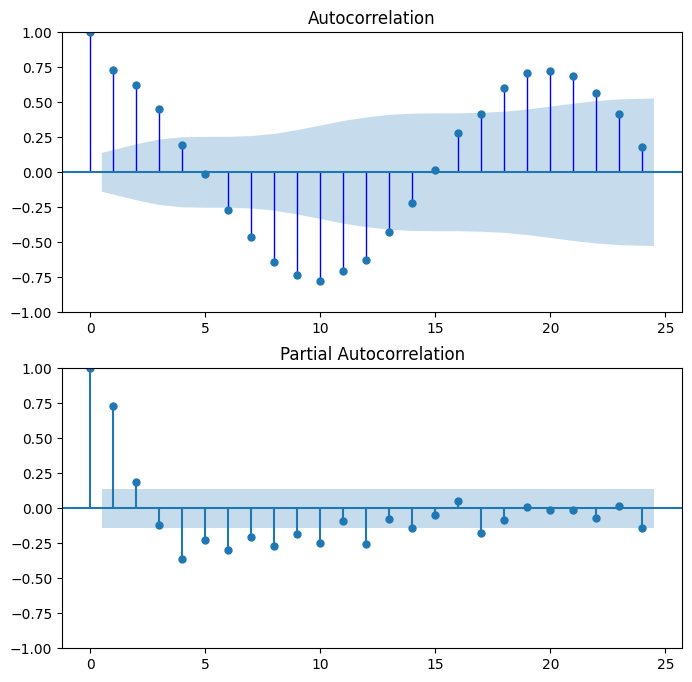

In [176]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['decomp_residuo']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['decomp_residuo']], ax=ax[1]);

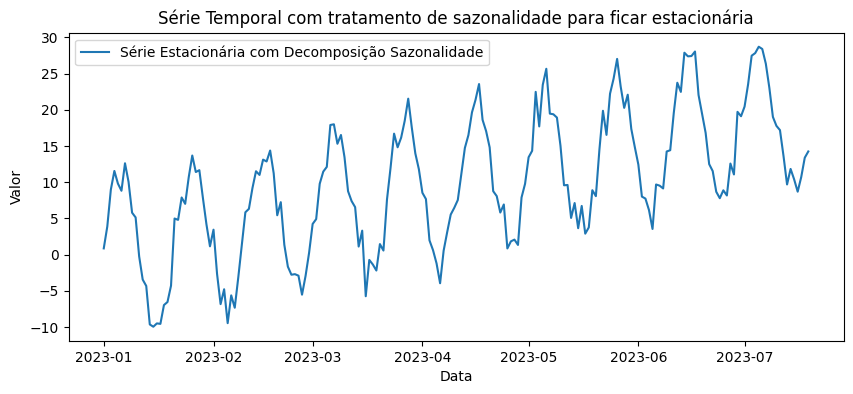

In [178]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['decomp_sazonalidade'], label='Série Estacionária com Decomposição Sazonalidade')
plt.title('Série Temporal com tratamento de sazonalidade para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [ ]:
# Sazonalidade não deixou a série estacionária
stat_test(df, 'decomp_sazonalidade')

ADFULLER: (np.float64(-0.6635484610154403), np.float64(0.8559667756445004), 15, 184, {'1%': np.float64(-3.466398230774071), '5%': np.float64(-2.8773796387256514), '10%': np.float64(-2.575213838610586)}, np.float64(793.813191535334))
KPSS: (np.float64(1.1726819214795658), np.float64(0.01), 9, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


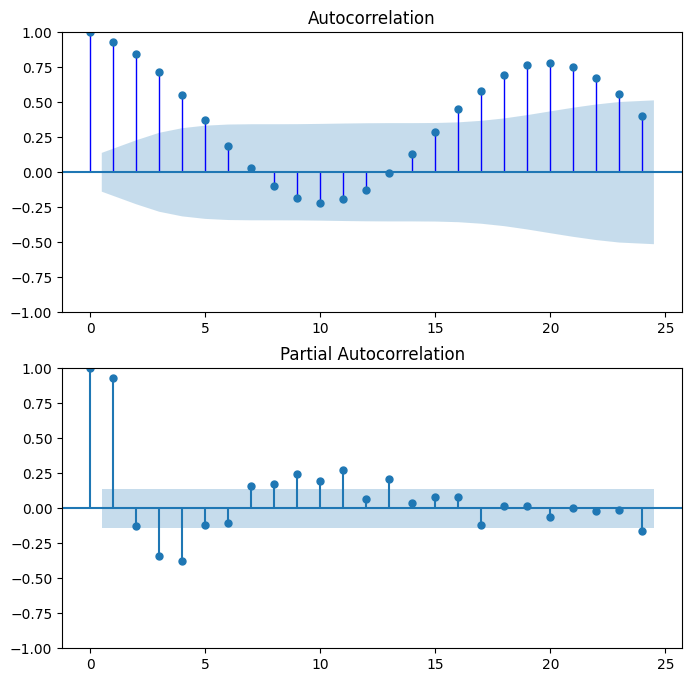

In [180]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['decomp_sazonalidade']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['decomp_sazonalidade']], ax=ax[1]);

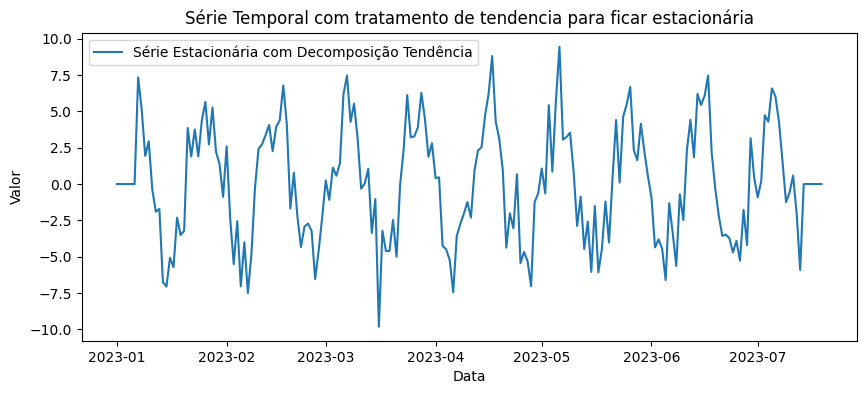

In [181]:
plt.figure(figsize=(10,4))
plt.plot(df['Data'], df['decomp_tendencia'], label='Série Estacionária com Decomposição Tendência')
plt.title('Série Temporal com tratamento de tendencia para ficar estacionária')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.show()

In [182]:
stat_test(df, 'decomp_tendencia')

ADFULLER: (np.float64(-8.391919920659157), np.float64(2.3540898667290847e-13), 14, 185, {'1%': np.float64(-3.4662005731940853), '5%': np.float64(-2.8772932777920364), '10%': np.float64(-2.575167750182615)}, np.float64(788.400455910005))
KPSS: (np.float64(0.01326194188539936), np.float64(0.1), 8, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


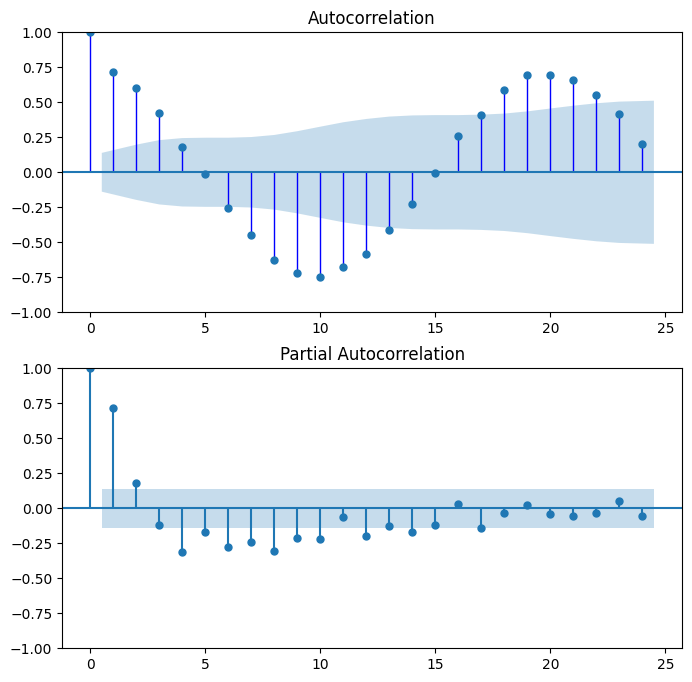

In [183]:
_, ax = plt.subplots(2, 1, figsize=(8, 8))
plot_acf(df[['decomp_tendencia']], alpha=.05, vlines_kwargs={'colors': 'blue', 'linewidth': 1}, ax=ax[0])
plot_pacf(df[['decomp_tendencia']], ax=ax[1]);

# Base para modelagem

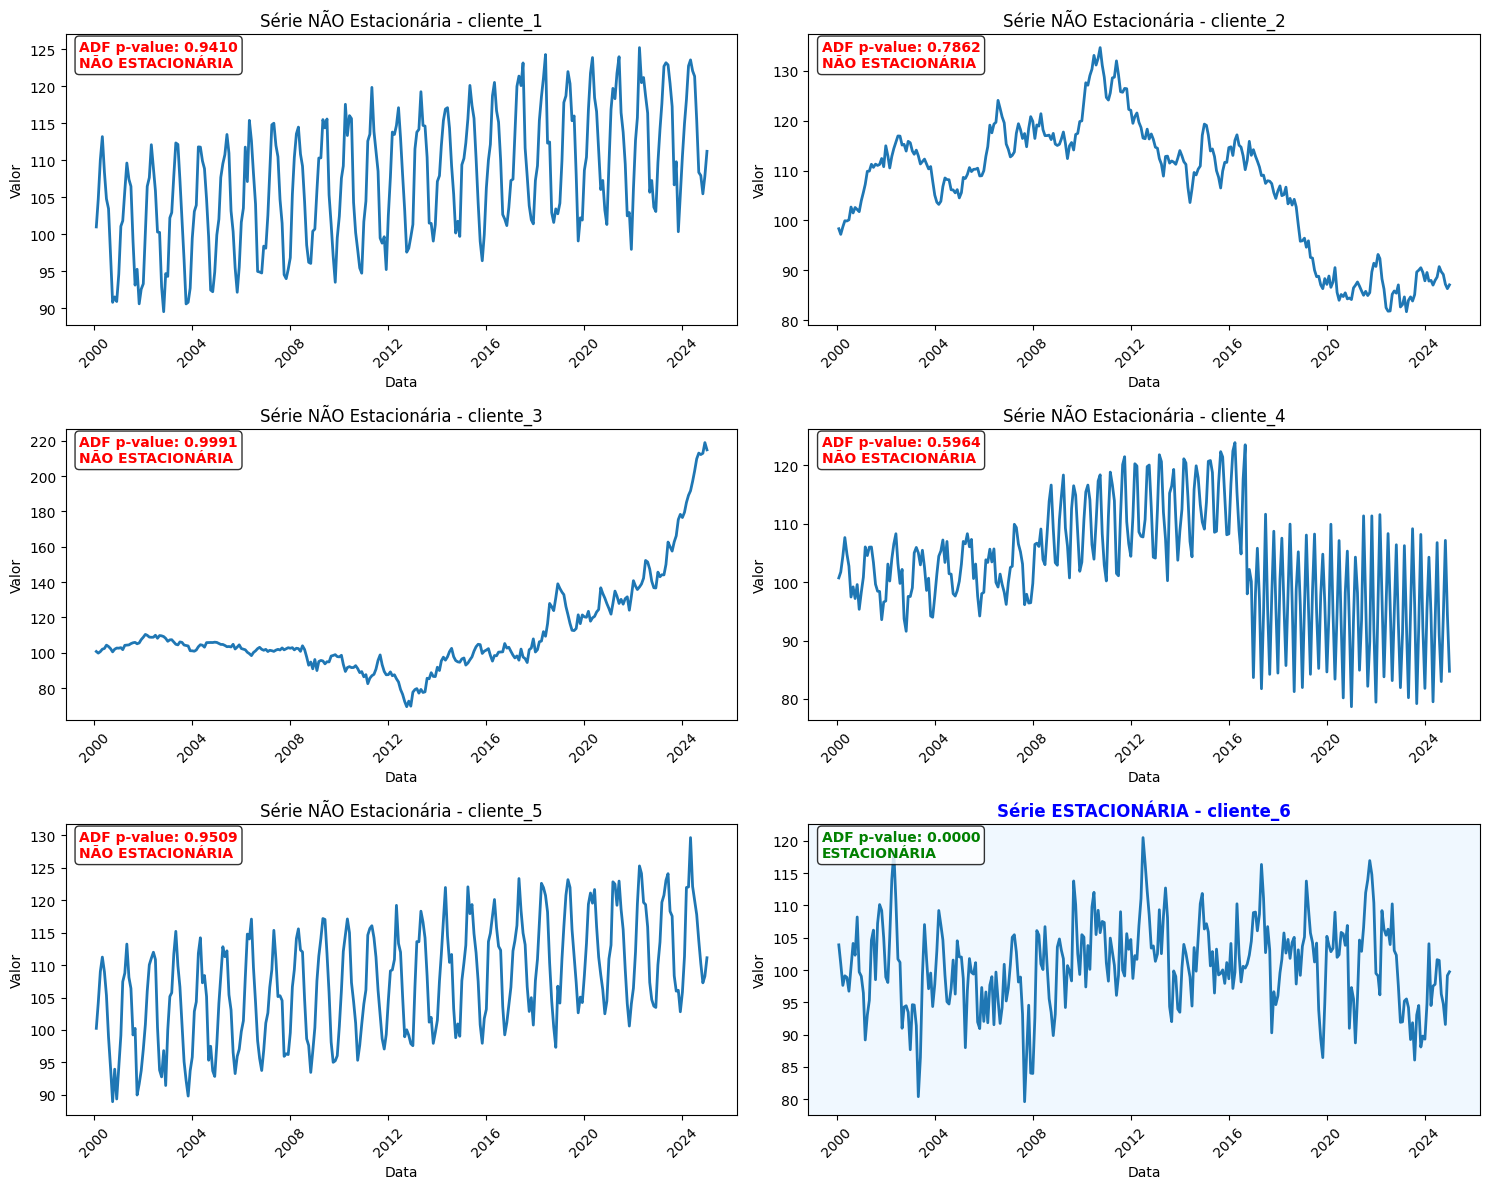

In [337]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Configurações
np.random.seed(42)  # Para reproducibilidade
n_points = 300
n_clientes = 6  # Agora são 6 clientes
data_inicio = '2000-01-01'

# Criar datas mensais
datas = pd.date_range(start=data_inicio, periods=n_points, freq='M')

# Criar DataFrame
df = pd.DataFrame({'data': np.tile(datas, n_clientes)})

# Adicionar IDs dos clientes
df['cliente_id'] = np.repeat([f'cliente_{i+1}' for i in range(n_clientes)], n_points)

# Função para criar série temporal não estacionária
def criar_serie_nao_estacionaria(n, tipo='tendencia_sazonal'):
    t = np.arange(n)
    
    if tipo == 'tendencia_sazonal':
        # Componentes não estacionários
        tendencia = 0.05 * t  # Tendência linear
        sazonalidade = 10 * np.sin(2 * np.pi * t / 12)  # Sazonalidade anual
        ruido = np.random.normal(0, 2, n)  # Ruído
        return tendencia + sazonalidade + ruido + 100  # Nível base
    
    elif tipo == 'random_walk':
        # Random walk (passeio aleatório)
        return np.cumsum(np.random.normal(0, 2, n)) + 100
    
    elif tipo == 'mudanca_variancia':
        # Mudança na variância ao longo do tempo
        variancia = np.where(t < 100, 1, 
                            np.where(t < 200, 3, 5))
        return np.cumsum(np.random.normal(0, variancia, n)) + 100
    
    elif tipo == 'combinado':
        # Combinação de diferentes padrões
        parte1 = 0.03 * t[:100] + 5 * np.sin(2 * np.pi * t[:100] / 12)
        parte2 = 0.08 * t[100:200] + 8 * np.sin(2 * np.pi * t[100:200] / 6)
        parte3 = -0.02 * t[200:] + 12 * np.sin(2 * np.pi * t[200:] / 4)
        return np.concatenate([parte1, parte2, parte3]) + np.random.normal(0, 2, n) + 100
    
    else:
        raise ValueError(f"Tipo {tipo} não reconhecido")

# Função para criar série ESTACIONÁRIA
def criar_serie_estacionaria(n):
    """
    Cria uma série temporal estacionária (ARMA-like)
    Média e variância constantes ao longo do tempo
    """
    t = np.arange(n)
    
    # Processo estacionário: AR(1) com coeficiente < 1
    serie = np.zeros(n)
    serie[0] = np.random.normal(100, 5)  # Valor inicial
    
    # Parâmetros do processo AR(1)
    phi = 0.7  # Coeficiente AR (deve ser |phi| < 1 para estacionariedade)
    mu = 100   # Média do processo
    sigma = 5  # Desvio padrão do ruído
    
    # Gerar processo AR(1) estacionário
    for i in range(1, n):
        serie[i] = mu + phi * (serie[i-1] - mu) + np.random.normal(0, sigma)
    
    # Adicionar um pouco de sazonalidade fraca (ainda mantém estacionariedade)
    sazonalidade_fraca = 2 * np.sin(2 * np.pi * t / 12)
    
    return serie + sazonalidade_fraca

# Criar séries temporais para cada cliente
padroes = ['tendencia_sazonal', 'random_walk', 'mudanca_variancia', 'combinado', 'tendencia_sazonal', 'estacionaria']
valores = []

for i, padrao in enumerate(padroes):
    if padrao == 'estacionaria':
        serie = criar_serie_estacionaria(n_points)
    else:
        serie = criar_serie_nao_estacionaria(n_points, padrao)
    valores.extend(serie)

df['valor'] = valores

# Ordenar por cliente e data
df = df.sort_values(['cliente_id', 'data']).reset_index(drop=True)

# Função para testar estacionariedade
def testar_estacionariedade(serie, nome):
    """Testa estacionariedade usando Dickey-Fuller aumentado"""
    resultado = adfuller(serie.dropna())
    return {
        'cliente': nome,
        'estatistica_adf': resultado[0],
        'p_valor': resultado[1],
        'estacionaria': resultado[1] <= 0.05
    }

# # Testar estacionariedade das séries originais
# print("=== TESTE DE ESTACIONARIEDADE - SÉRIES ORIGINAIS ===")
resultados_originais = []
for cliente in df['cliente_id'].unique():
    dados_cliente = df[df['cliente_id'] == cliente]['valor']
    resultado = testar_estacionariedade(dados_cliente, cliente)
    resultados_originais.append(resultado)

df_resultados_originais = pd.DataFrame(resultados_originais)
# print(df_resultados_originais)

# Visualizar todas as séries
plt.figure(figsize=(15, 12))

# Plotar séries originais
for i, cliente in enumerate(df['cliente_id'].unique()):
    plt.subplot(3, 2, i+1)
    dados_cliente = df[df['cliente_id'] == cliente]
    plt.plot(dados_cliente['data'], dados_cliente['valor'], linewidth=2)
    
    # Destacar cliente estacionário
    if cliente == 'cliente_6':
        plt.gca().set_facecolor('#f0f8ff')  # Fundo azul claro
        plt.title(f'Série ESTACIONÁRIA - {cliente}', fontweight='bold', color='blue')
    else:
        plt.title(f'Série NÃO Estacionária - {cliente}')
    
    plt.xlabel('Data')
    plt.ylabel('Valor')
    plt.xticks(rotation=45)
    
    # Adicionar resultado do teste ADF no gráfico
    resultado = df_resultados_originais[df_resultados_originais['cliente'] == cliente].iloc[0]
    estacionaria_texto = "ESTACIONÁRIA" if resultado['estacionaria'] else "NÃO ESTACIONÁRIA"
    cor_texto = 'green' if resultado['estacionaria'] else 'red'
    plt.text(0.02, 0.98, f'ADF p-value: {resultado["p_valor"]:.4f}\n{estacionaria_texto}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             color=cor_texto, fontweight='bold')

plt.tight_layout()
plt.show()

# # Análise estatística comparativa
# print("\n=== ANÁLISE ESTATÍSTICA COMPARATIVA ===")
# estatisticas = df.groupby('cliente_id')['valor'].agg([
#     ('media', 'mean'),
#     ('desvio_padrao', 'std'),
#     ('variancia', 'var'),
#     ('coef_variacao', lambda x: np.std(x) / np.mean(x))
# ]).round(4)

# Adicionar informação de estacionariedade
estatisticas['estacionaria'] = df_resultados_originais.set_index('cliente')['estacionaria']
# print(estatisticas)

# Visualizar comparação de médias móveis (evidência de estacionariedade)
# plt.figure(figsize=(15, 10))

# # Calcular médias móveis para cada cliente
# window = 12  # Janela de 12 meses
# for i, cliente in enumerate(df['cliente_id'].unique()):
#     plt.subplot(3, 2, i+1)
#     dados_cliente = df[df['cliente_id'] == cliente].copy()
#     dados_cliente = dados_cliente.sort_values('data')
    
#     # Série original
#     plt.plot(dados_cliente['data'], dados_cliente['valor'], alpha=0.7, label='Série Original')
    
#     # Média móvel
#     dados_cliente['media_movel'] = dados_cliente['valor'].rolling(window=window).mean()
#     plt.plot(dados_cliente['data'], dados_cliente['media_movel'], 
#              color='red', linewidth=2, label=f'Média Móvel ({window} meses)')
    
#     if cliente == 'cliente_6':
#         plt.title(f'Cliente 6 (Estacionário)\nMédia Móvel Constante', fontweight='bold')
#     else:
#         plt.title(f'Cliente {cliente[-1]} (Não Estacionário)\nMédia Móvel Variável')
    
#     plt.xlabel('Data')
#     plt.ylabel('Valor')
#     plt.legend()
#     plt.xticks(rotation=45)

# plt.tight_layout()
# plt.show()

# # Mostrar primeiras linhas dos dados
# print("\n=== PRIMEIRAS LINHAS DOS DADOS ===")
# print(df.head(18))  # Mostra 3 linhas por cliente (6 clientes × 3 = 18)

In [213]:
df.sort_values(by='data', inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,data,cliente_id,valor
0,2000-01-31,cliente_1,100.993428
1,2000-01-31,cliente_3,100.756989
2,2000-01-31,cliente_4,100.737347
3,2000-01-31,cliente_5,100.250449
4,2000-01-31,cliente_6,103.891805


## Modelos com statsforecast

In [256]:
# Primeiro modelo usando statsforecast, sem tratamento da estacionariedade
from statsforecast import StatsForecast
from statsforecast.models import Naive

In [257]:
# Implementacao do wmape pois nao existe no sklearn
def wmape(y_true, y_pred):
    return np.abs(y_true - y_pred).sum() / np.abs(y_true).sum()

In [258]:
# Separando em treino e teste
df_train = df[df.data <= '2022-12-31'].reset_index(drop=True)
df_test = df[df.data > '2022-12-31'].reset_index(drop=True)

In [259]:
# Renomeando as colunas para ficar no padrão desejado pelo modelo
mdl_cols = ['ds', 'unique_id', 'y']
df_train.columns = ['ds', 'unique_id', 'y']
df_test.columns = ['ds', 'unique_id', 'y']

WMAPE: 10.42%


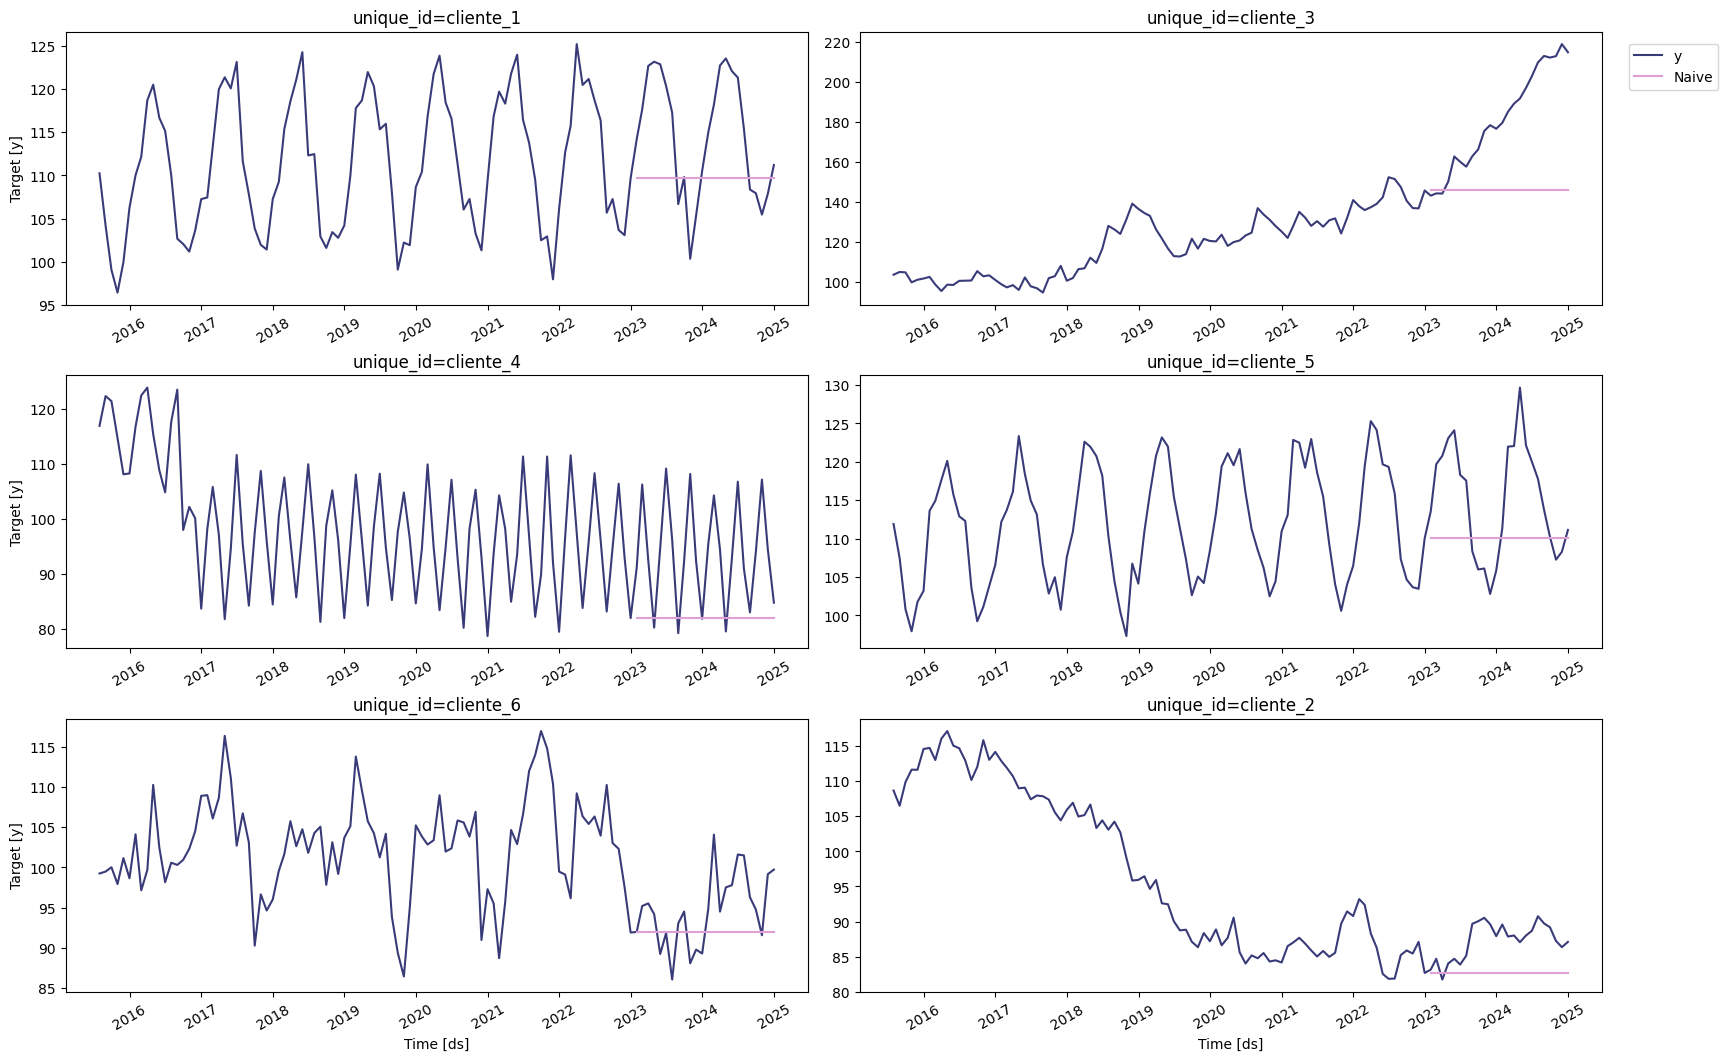

In [260]:
model = StatsForecast(models=[Naive()], freq='M', n_jobs=-1)
model.fit(df_train)

# Em h 24 é o horizonte, ou seja, irei prever 24 meses a frente
forecast_df = model.predict(h=24, level=[90])
forecast_df = forecast_df.reset_index(drop=True).merge(df_test, on=['ds', 'unique_id'], how='left')

wmape_ = wmape(forecast_df['y'].values, forecast_df['Naive'].values)
print(f'WMAPE: {wmape_:.2%}')

model.plot(df_train, forecast_df, engine='matplotlib', max_insample_length=90)

In [264]:
forecast_df['percent'] = forecast_df.apply(lambda x: x['Naive'] / x['y'], axis=1)
forecast_df['percent'].mean()

np.float64(0.9237856568553542)

WMAPE: 10.85%


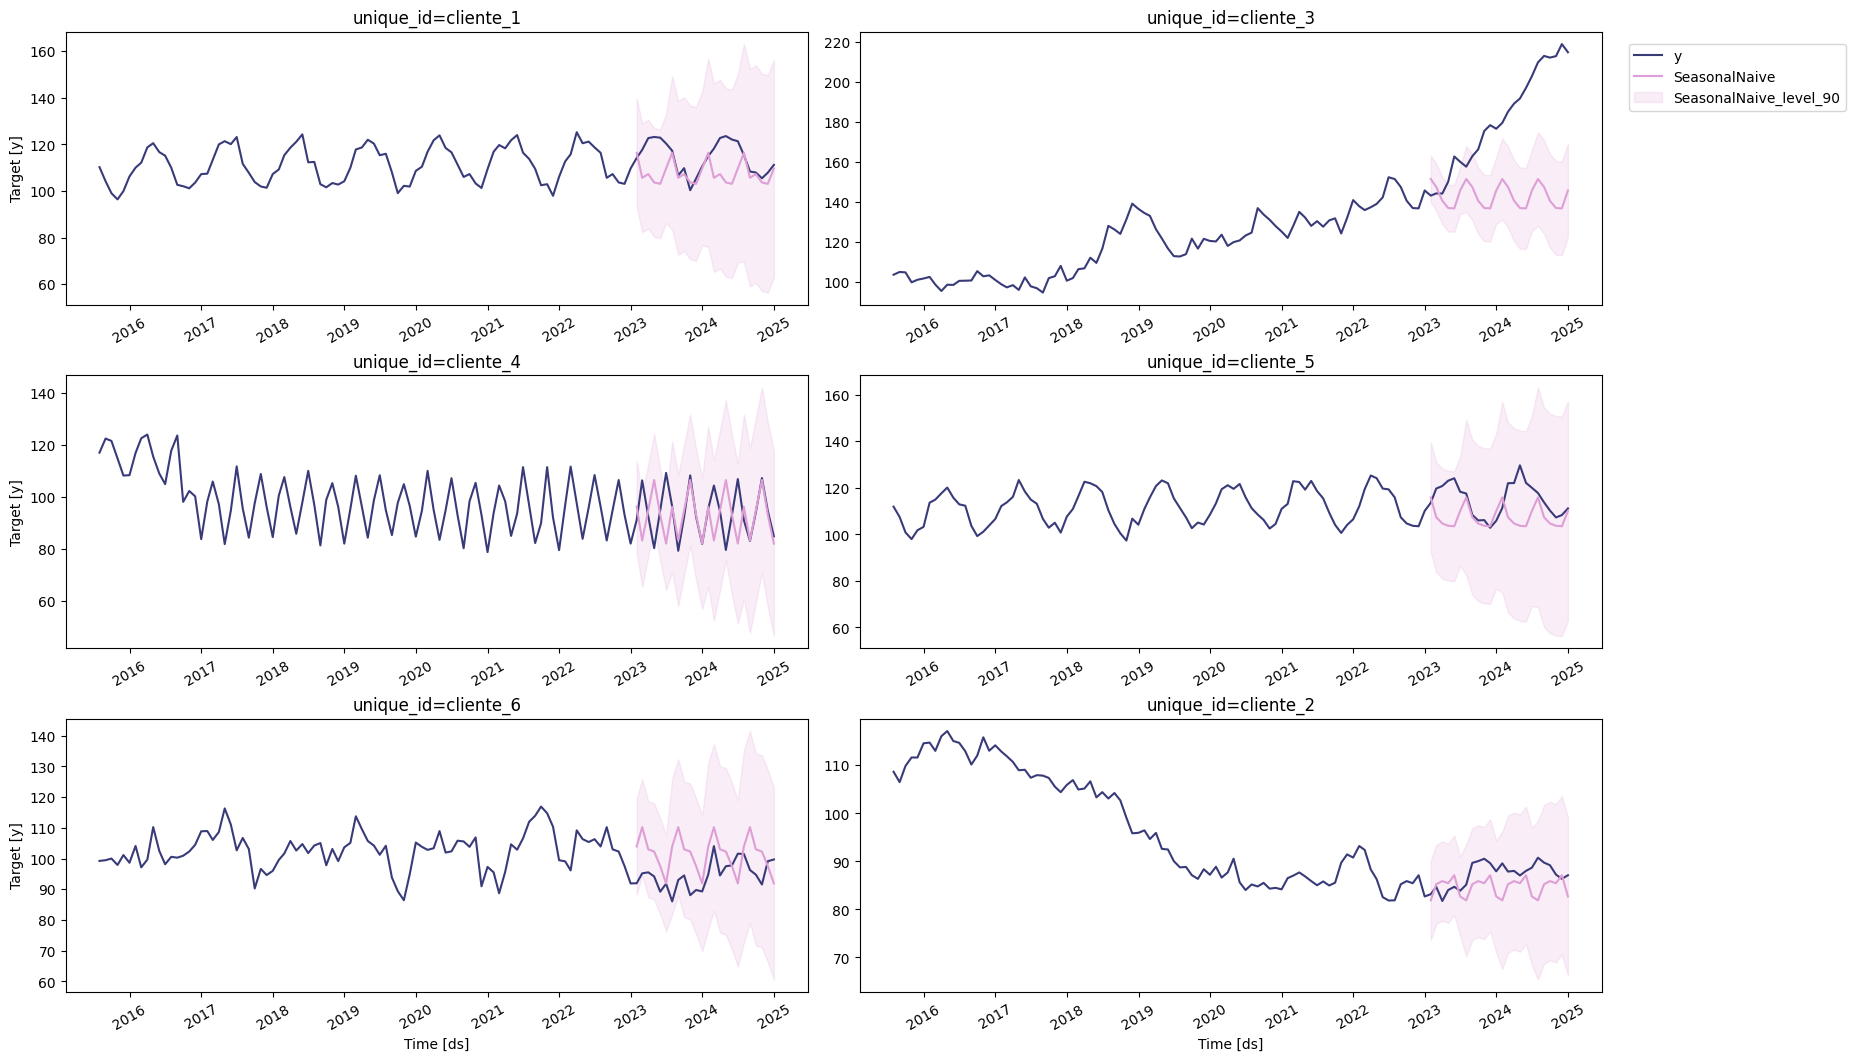

In [265]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

model = StatsForecast(models=[SeasonalNaive(season_length=6)], freq='M', n_jobs=-1)
model.fit(df_train)

forecast_df = model.predict(h=24, level=[90])
forecast_df = forecast_df.reset_index(drop=True).merge(df_test, on=['ds', 'unique_id'], how='left')

wmape_ = wmape(forecast_df['y'].values, forecast_df['SeasonalNaive'].values)
print(f'WMAPE: {wmape_:.2%}')

model.plot(df_train, forecast_df, level=[90], engine='matplotlib', max_insample_length=90)

In [268]:
forecast_df['percent'] = forecast_df.apply(lambda x: x['SeasonalNaive'] / x['y'], axis=1)
forecast_df['percent'].mean()

np.float64(0.9546039272244305)

WMAPE: 10.27%


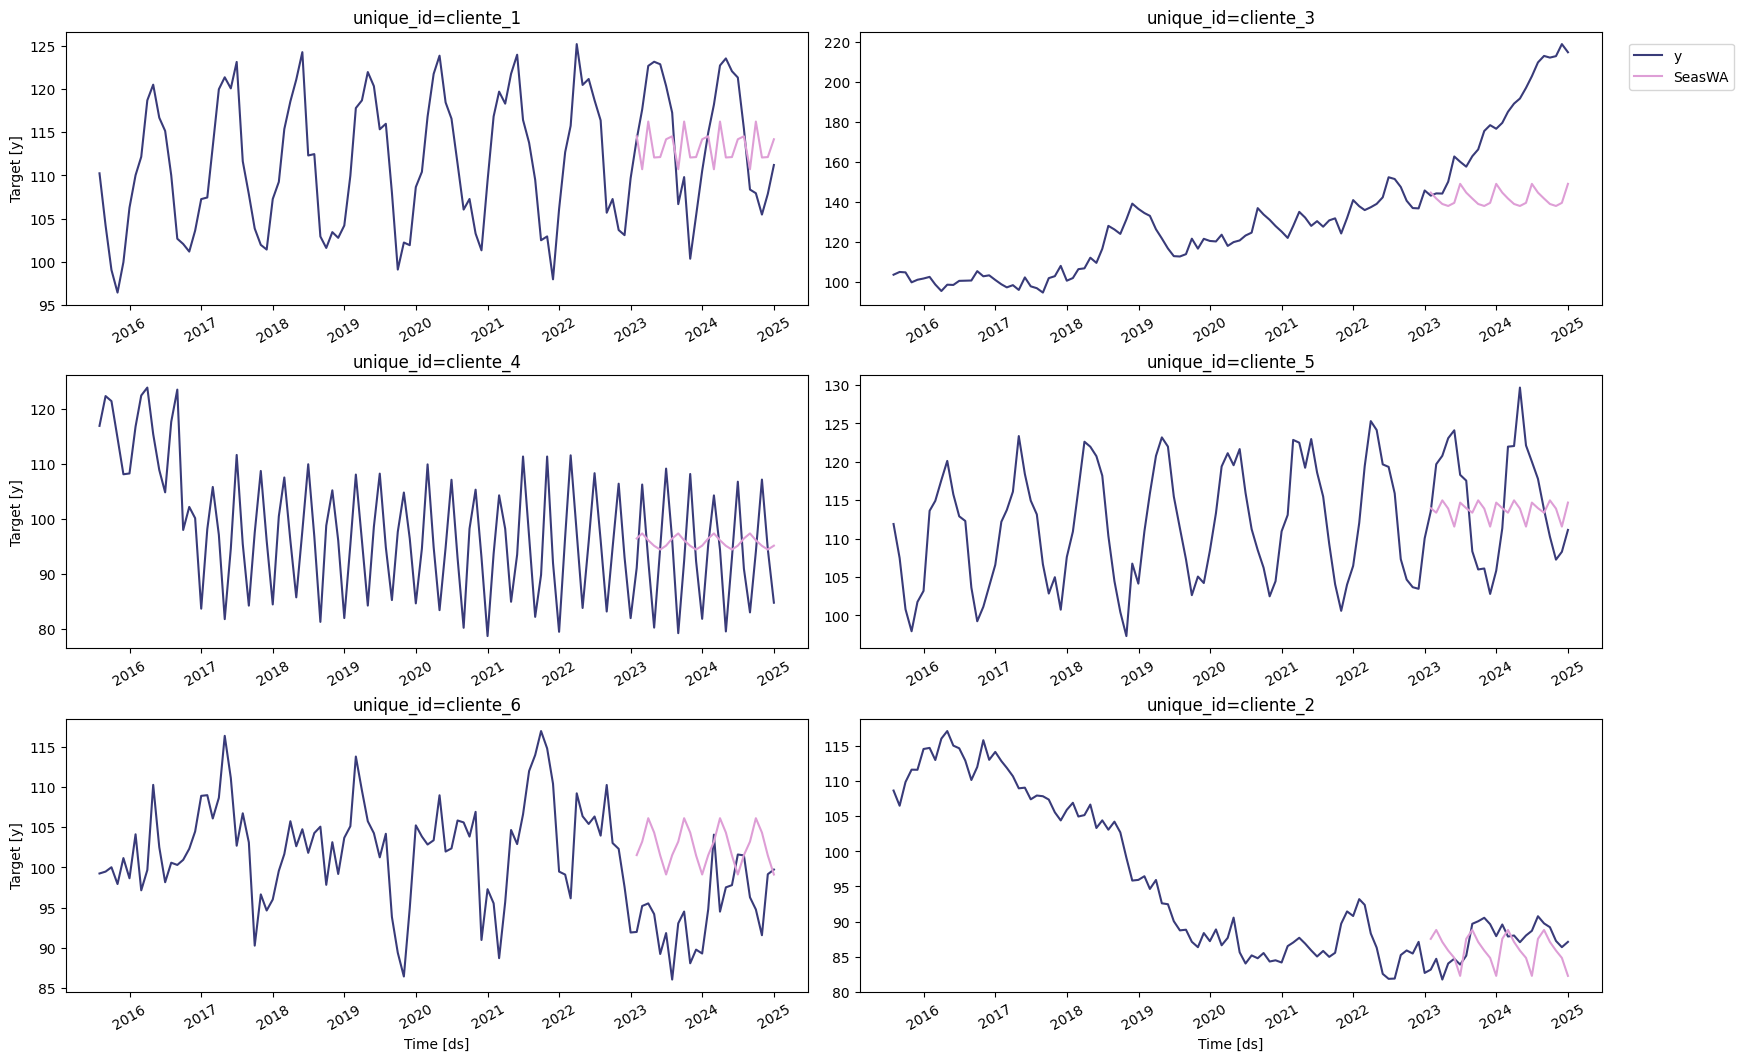

In [272]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalWindowAverage

model = StatsForecast(models=[SeasonalWindowAverage(season_length=6, window_size=2)], freq='M', n_jobs=-1)
model.fit(df_train)

forecast_df = model.predict(h=24)
forecast_df = forecast_df.reset_index(drop=True).merge(df_test, on=['ds', 'unique_id'], how='left')

wmape_ = wmape(forecast_df['y'].values, forecast_df['SeasWA'].values)
print(f'WMAPE: {wmape_:.2%}')

model.plot(df_train, forecast_df, engine='matplotlib', max_insample_length=90)

In [274]:
forecast_df['percent'] = forecast_df.apply(lambda x: x['SeasWA'] / x['y'], axis=1)
forecast_df['percent'].mean()

np.float64(0.9810854849112446)

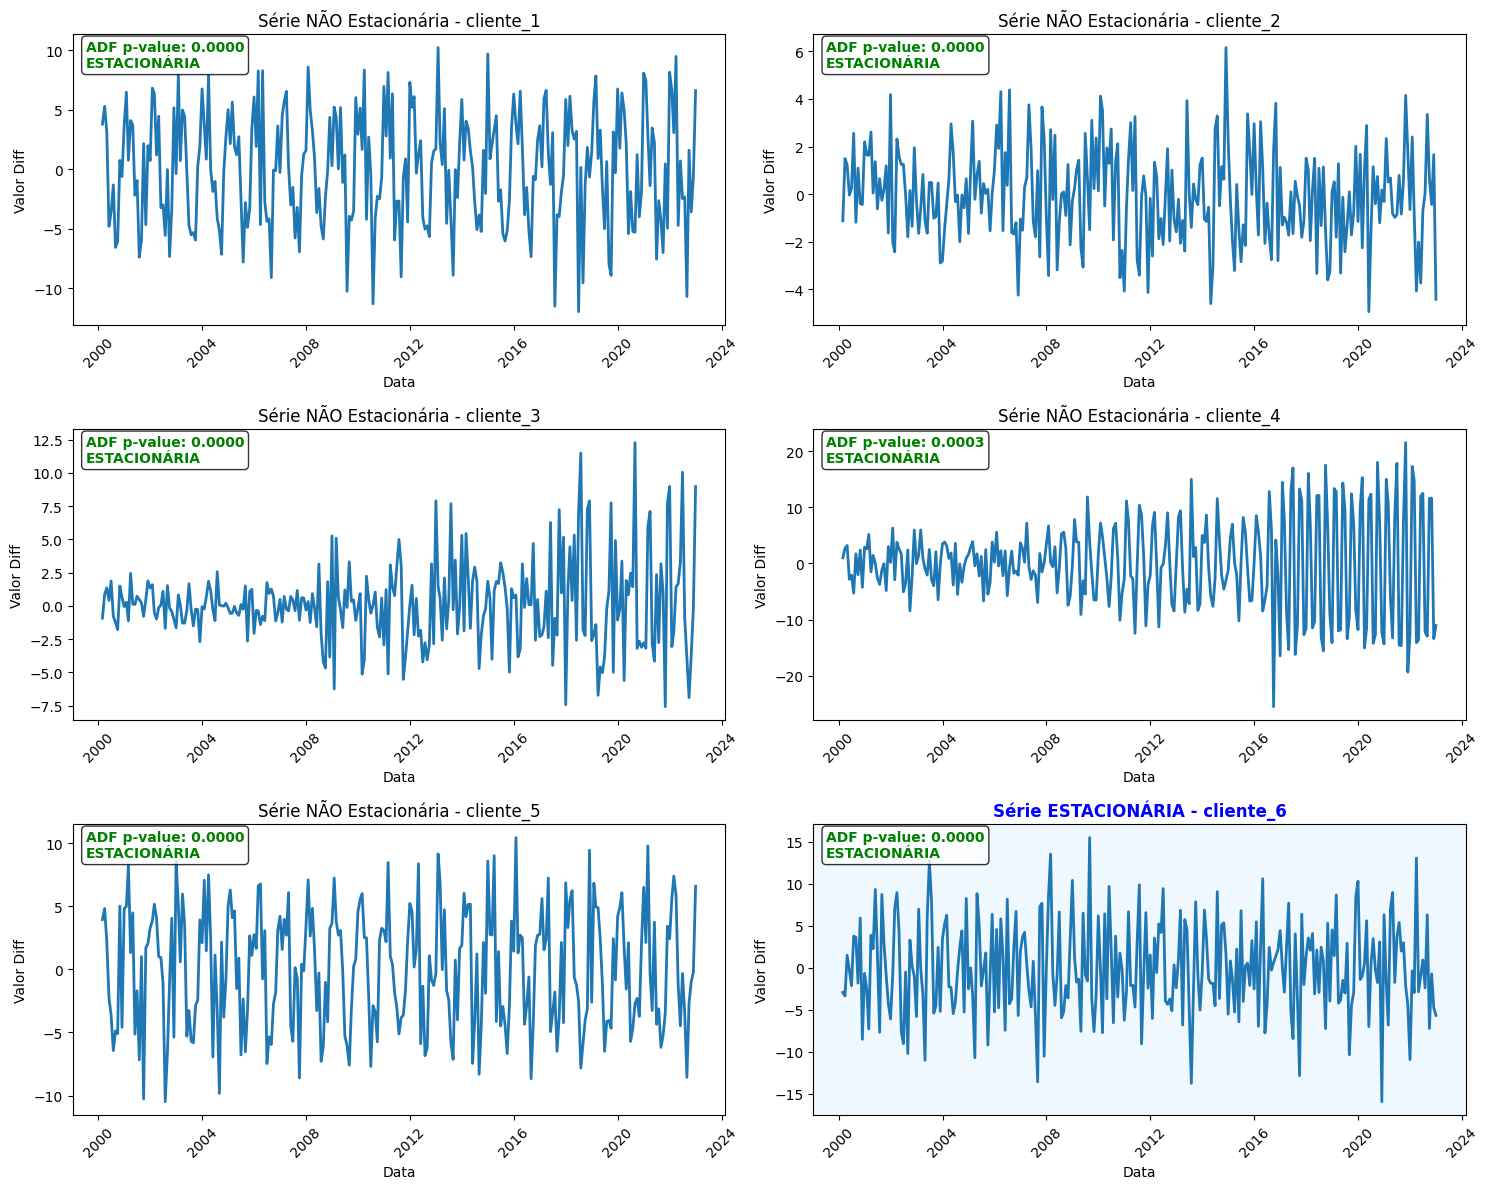

In [404]:
# Modelos com tratamento de estacionariedade diff
df_diff = df.copy()
df_train = df_diff[df_diff.data <= '2022-12-31']
df_test = df_diff[df_diff.data > '2022-12-31']
df_train['diff'] = df_train.groupby('cliente_id')['valor'].diff()
df_train.dropna(inplace=True)

last_value_train = df_train.iloc[-1][2]

# Testar estacionariedade das séries originais
# print("=== TESTE DE ESTACIONARIEDADE - SÉRIES ORIGINAIS ===")
resultados_originais = []
for cliente in df_train['cliente_id'].unique():
    dados_cliente = df_train[df_train['cliente_id'] == cliente]['diff']
    resultado = testar_estacionariedade(dados_cliente, cliente)
    resultados_originais.append(resultado)

df_resultados_originais = pd.DataFrame(resultados_originais)


# Visualizar todas as séries
plt.figure(figsize=(15, 12))

# Plotar séries originais
for i, cliente in enumerate(df_train['cliente_id'].unique()):
    plt.subplot(3, 2, i+1)
    dados_cliente = df_train[df_train['cliente_id'] == cliente]
    plt.plot(dados_cliente['data'], dados_cliente['diff'], linewidth=2)
    
    # Destacar cliente estacionário
    if cliente == 'cliente_6':
        plt.gca().set_facecolor('#f0f8ff')  # Fundo azul claro
        plt.title(f'Série ESTACIONÁRIA - {cliente}', fontweight='bold', color='blue')
    else:
        plt.title(f'Série NÃO Estacionária - {cliente}')
    
    plt.xlabel('Data')
    plt.ylabel('Valor Diff')
    plt.xticks(rotation=45)
    
    # Adicionar resultado do teste ADF no gráfico
    resultado = df_resultados_originais[df_resultados_originais['cliente'] == cliente].iloc[0]
    estacionaria_texto = "ESTACIONÁRIA" if resultado['estacionaria'] else "NÃO ESTACIONÁRIA"
    cor_texto = 'green' if resultado['estacionaria'] else 'red'
    plt.text(0.02, 0.98, f'ADF p-value: {resultado["p_valor"]:.4f}\n{estacionaria_texto}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             color=cor_texto, fontweight='bold')

plt.tight_layout()
plt.show()

In [393]:
last_value_train

np.float64(91.90734682276255)

In [409]:
mdl_cols = ['ds', 'unique_id', 'y']
df_train.rename(columns={'data': 'ds', 'cliente_id': 'unique_id', 'diff': 'y'}, inplace=True)
# df_train.columns = ['ds', 'unique_id', 'y']
df_test.columns = ['ds', 'unique_id', 'y']

In [411]:
model = StatsForecast(models=[Naive(), SeasonalNaive(season_length=6)], freq='M', n_jobs=-1)
model.fit(df_train[['ds', 'unique_id', 'y']])

# Em h 24 é o horizonte, ou seja, irei prever 24 meses a frente
forecast_df = model.predict(h=24, level=[90])
forecast_df = (
    forecast_df
    .reset_index(drop=True)
    .merge(df_test, on=['ds', 'unique_id'], how='left'))

# model.plot(df_train, forecast_df, engine='matplotlib', max_insample_length=90)

In [412]:
# def reverse_diff(original_series, diff_forecast, last_observation):
#     """
#     Reverte a diferenciação para obter previsões na escala original
    
#     original_series: série temporal original
#     diff_forecast: previsões da série diferenciada
#     last_observation: última observação da série original
#     """
#     # Para diferenciação de primeira ordem: y_t = y_{t-1} + Δy_t
#     forecast_original = []
#     current = last_observation
    
#     for diff_value in diff_forecast:
#         current = current + diff_value
#         forecast_original.append(current)
    
#     return np.array(forecast_original)

def reverse_diff(diff_series, last_original_value):
    result = np.zeros(len(diff_series))
    result[0] = last_original_value + diff_series[0]

    for i in range(1, len(diff_series)):
        result[i] = result[i - 1] + diff_series[i]
    
    return np.array(result)

# Última observação da série original
last_obs = last_value_train

# Revertendo a diferenciação para cada modelo
for mdl in ['Naive', 'SeasonalNaive']:
    diff_predictions = forecast_df[mdl].values
    original_predictions = reverse_diff(diff_predictions, last_obs)
    forecast_df[f'{mdl}_original'] = original_predictions

wmape_ = wmape(forecast_df['y'].values, forecast_df['Naive_original'].values)
print(f'WMAPE Naive: {wmape_:.2%}')
wmape_ = wmape(forecast_df['y'].values, forecast_df['SeasonalNaive_original'].values)
print(f'WMAPE SeasonalNaive: {wmape_:.2%}')

WMAPE Naive: 76.24%
WMAPE SeasonalNaive: 113.22%


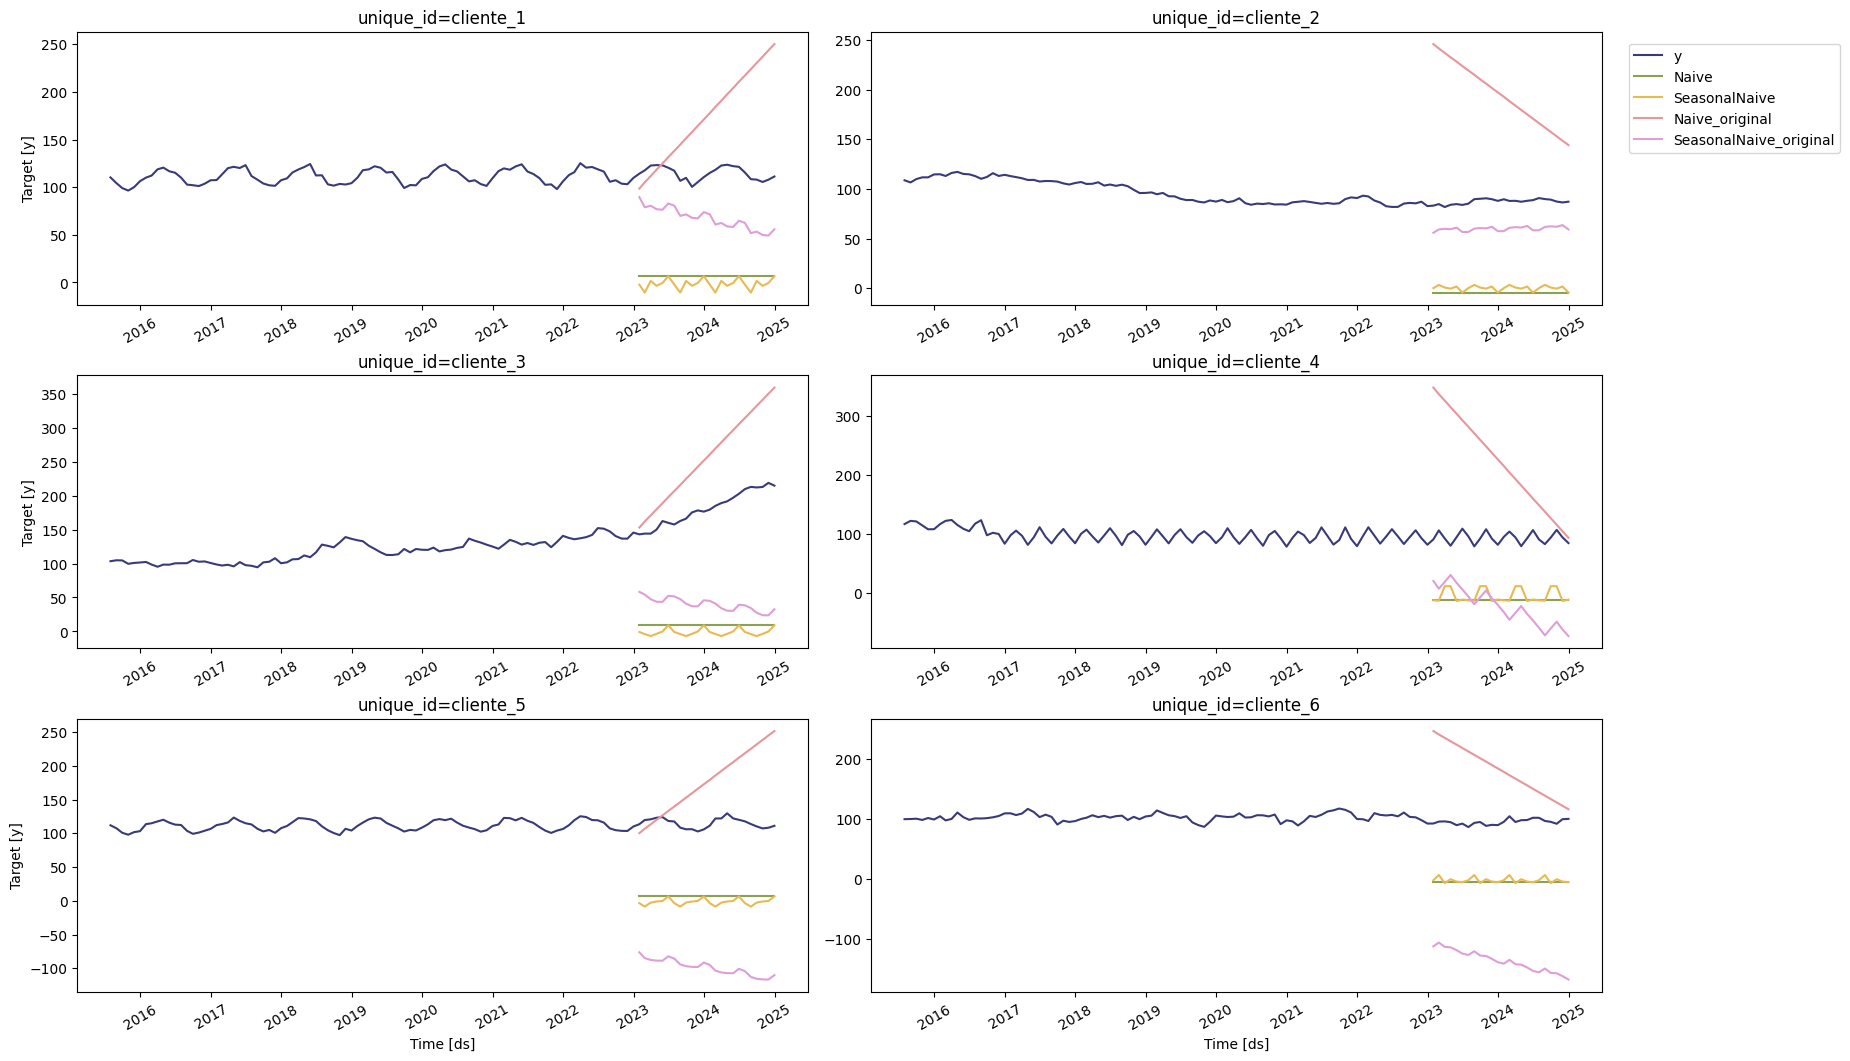

In [419]:
df_train.rename(columns={'y': 'y_diff', 'valor': 'y'}, inplace=True)
model.plot(df_train, forecast_df, engine='matplotlib', max_insample_length=90)

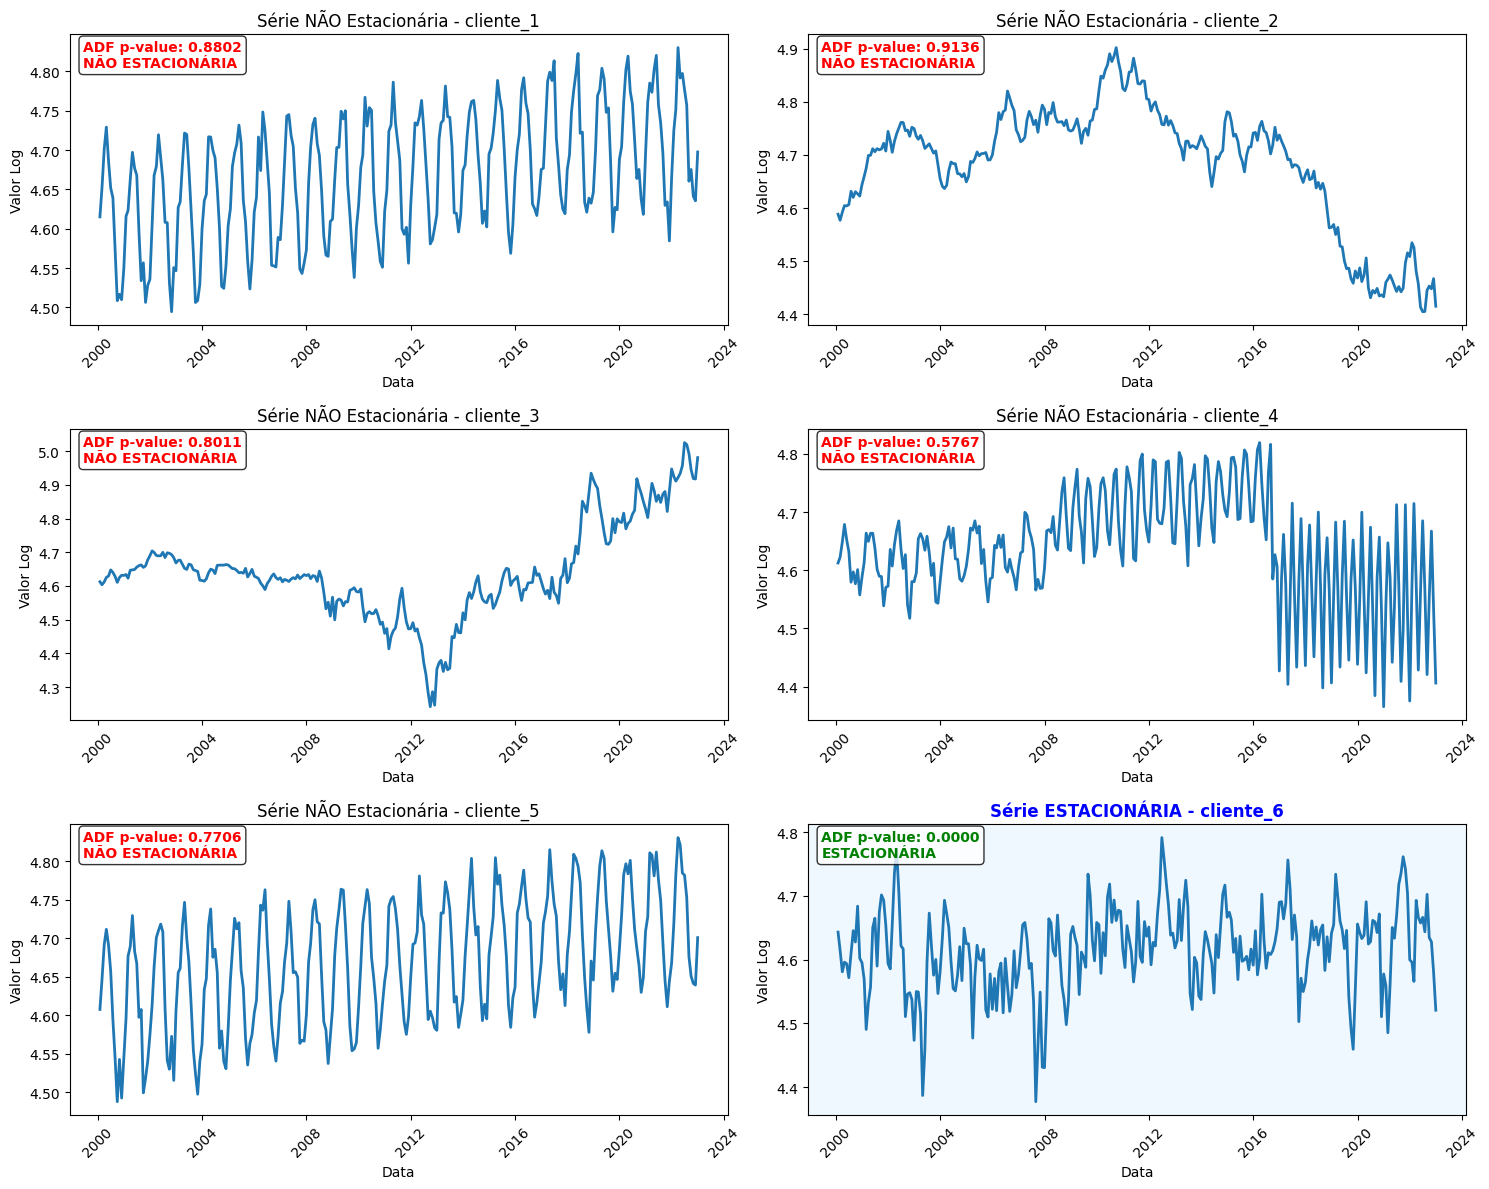

In [449]:
# Modelos com tratamento de estacionariedade log
# A aplicação de log não foi suficiente para deixar os dados estacionários
df_log = df.copy()
df_train = df_log[df_log.data <= '2022-12-31']
df_test = df_log[df_log.data > '2022-12-31']
df_train['log'] = df_train.groupby('cliente_id')['valor'].transform(lambda x: np.log(x))


# Testar estacionariedade das séries originais
# print("=== TESTE DE ESTACIONARIEDADE - SÉRIES ORIGINAIS ===")
resultados_originais = []
for cliente in df_train['cliente_id'].unique():
    dados_cliente = df_train[df_train['cliente_id'] == cliente]['log']
    resultado = testar_estacionariedade(dados_cliente, cliente)
    resultados_originais.append(resultado)

df_resultados_originais = pd.DataFrame(resultados_originais)

# Visualizar todas as séries
plt.figure(figsize=(15, 12))

# Plotar séries originais
for i, cliente in enumerate(df_train['cliente_id'].unique()):
    plt.subplot(3, 2, i+1)
    dados_cliente = df_train[df_train['cliente_id'] == cliente]
    plt.plot(dados_cliente['data'], dados_cliente['log'], linewidth=2)
    
    # Destacar cliente estacionário
    if cliente == 'cliente_6':
        plt.gca().set_facecolor('#f0f8ff')  # Fundo azul claro
        plt.title(f'Série ESTACIONÁRIA - {cliente}', fontweight='bold', color='blue')
    else:
        plt.title(f'Série NÃO Estacionária - {cliente}')
    
    plt.xlabel('Data')
    plt.ylabel('Valor Log')
    plt.xticks(rotation=45)
    
    # Adicionar resultado do teste ADF no gráfico
    resultado = df_resultados_originais[df_resultados_originais['cliente'] == cliente].iloc[0]
    estacionaria_texto = "ESTACIONÁRIA" if resultado['estacionaria'] else "NÃO ESTACIONÁRIA"
    cor_texto = 'green' if resultado['estacionaria'] else 'red'
    plt.text(0.02, 0.98, f'ADF p-value: {resultado["p_valor"]:.4f}\n{estacionaria_texto}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
             color=cor_texto, fontweight='bold')

plt.tight_layout()
plt.show()

In [462]:
# Modelando com Profhet, pois ele é robusto a outliers e a não estacionariedade da base
from prophet import Prophet

df_prophet = df.copy()
df_prophet = df_prophet[['cliente_id', 'data', 'valor']]
df_prophet.columns = ['cliente_id', 'ds', 'y']
df_train = df_prophet[df_prophet.ds <= '2022-12-31']
df_test = df_prophet[df_prophet.ds > '2022-12-31']

res = []
for cl in df_train.cliente_id.unique():
    temp_df = df_train[df_train.cliente_id == cl]
    m = Prophet()
    m.fit(temp_df[['ds', 'y']])
    future = m.make_future_dataframe(periods=24, freq='M')
    forecast = m.predict(future)
    res.append(forecast)

21:48:34 - cmdstanpy - INFO - Chain [1] start processing
21:48:34 - cmdstanpy - INFO - Chain [1] done processing
21:48:34 - cmdstanpy - INFO - Chain [1] start processing
21:48:34 - cmdstanpy - INFO - Chain [1] done processing
21:48:34 - cmdstanpy - INFO - Chain [1] start processing
21:48:34 - cmdstanpy - INFO - Chain [1] done processing
21:48:34 - cmdstanpy - INFO - Chain [1] start processing
21:48:34 - cmdstanpy - INFO - Chain [1] done processing
21:48:34 - cmdstanpy - INFO - Chain [1] start processing
21:48:34 - cmdstanpy - INFO - Chain [1] done processing
21:48:34 - cmdstanpy - INFO - Chain [1] start processing
21:48:34 - cmdstanpy - INFO - Chain [1] done processing


In [473]:
datas = []
for i in range(len(res)):
    temp = res[0][-24:][['ds', 'yhat']]
    temp['cliente_id'] = f'cliente_{i + 1}'
    datas.append(temp)

df_forecast = pd.concat(datas, ignore_index=True)

In [475]:
df_final = df_forecast.reset_index(drop=True).merge(df_test, on=['ds', 'cliente_id'], how='left')
wmape_ = wmape(df_final['y'].values, df_final['yhat'].values)
print(f'WMAPE: {wmape_:.2%}')

WMAPE: 19.99%


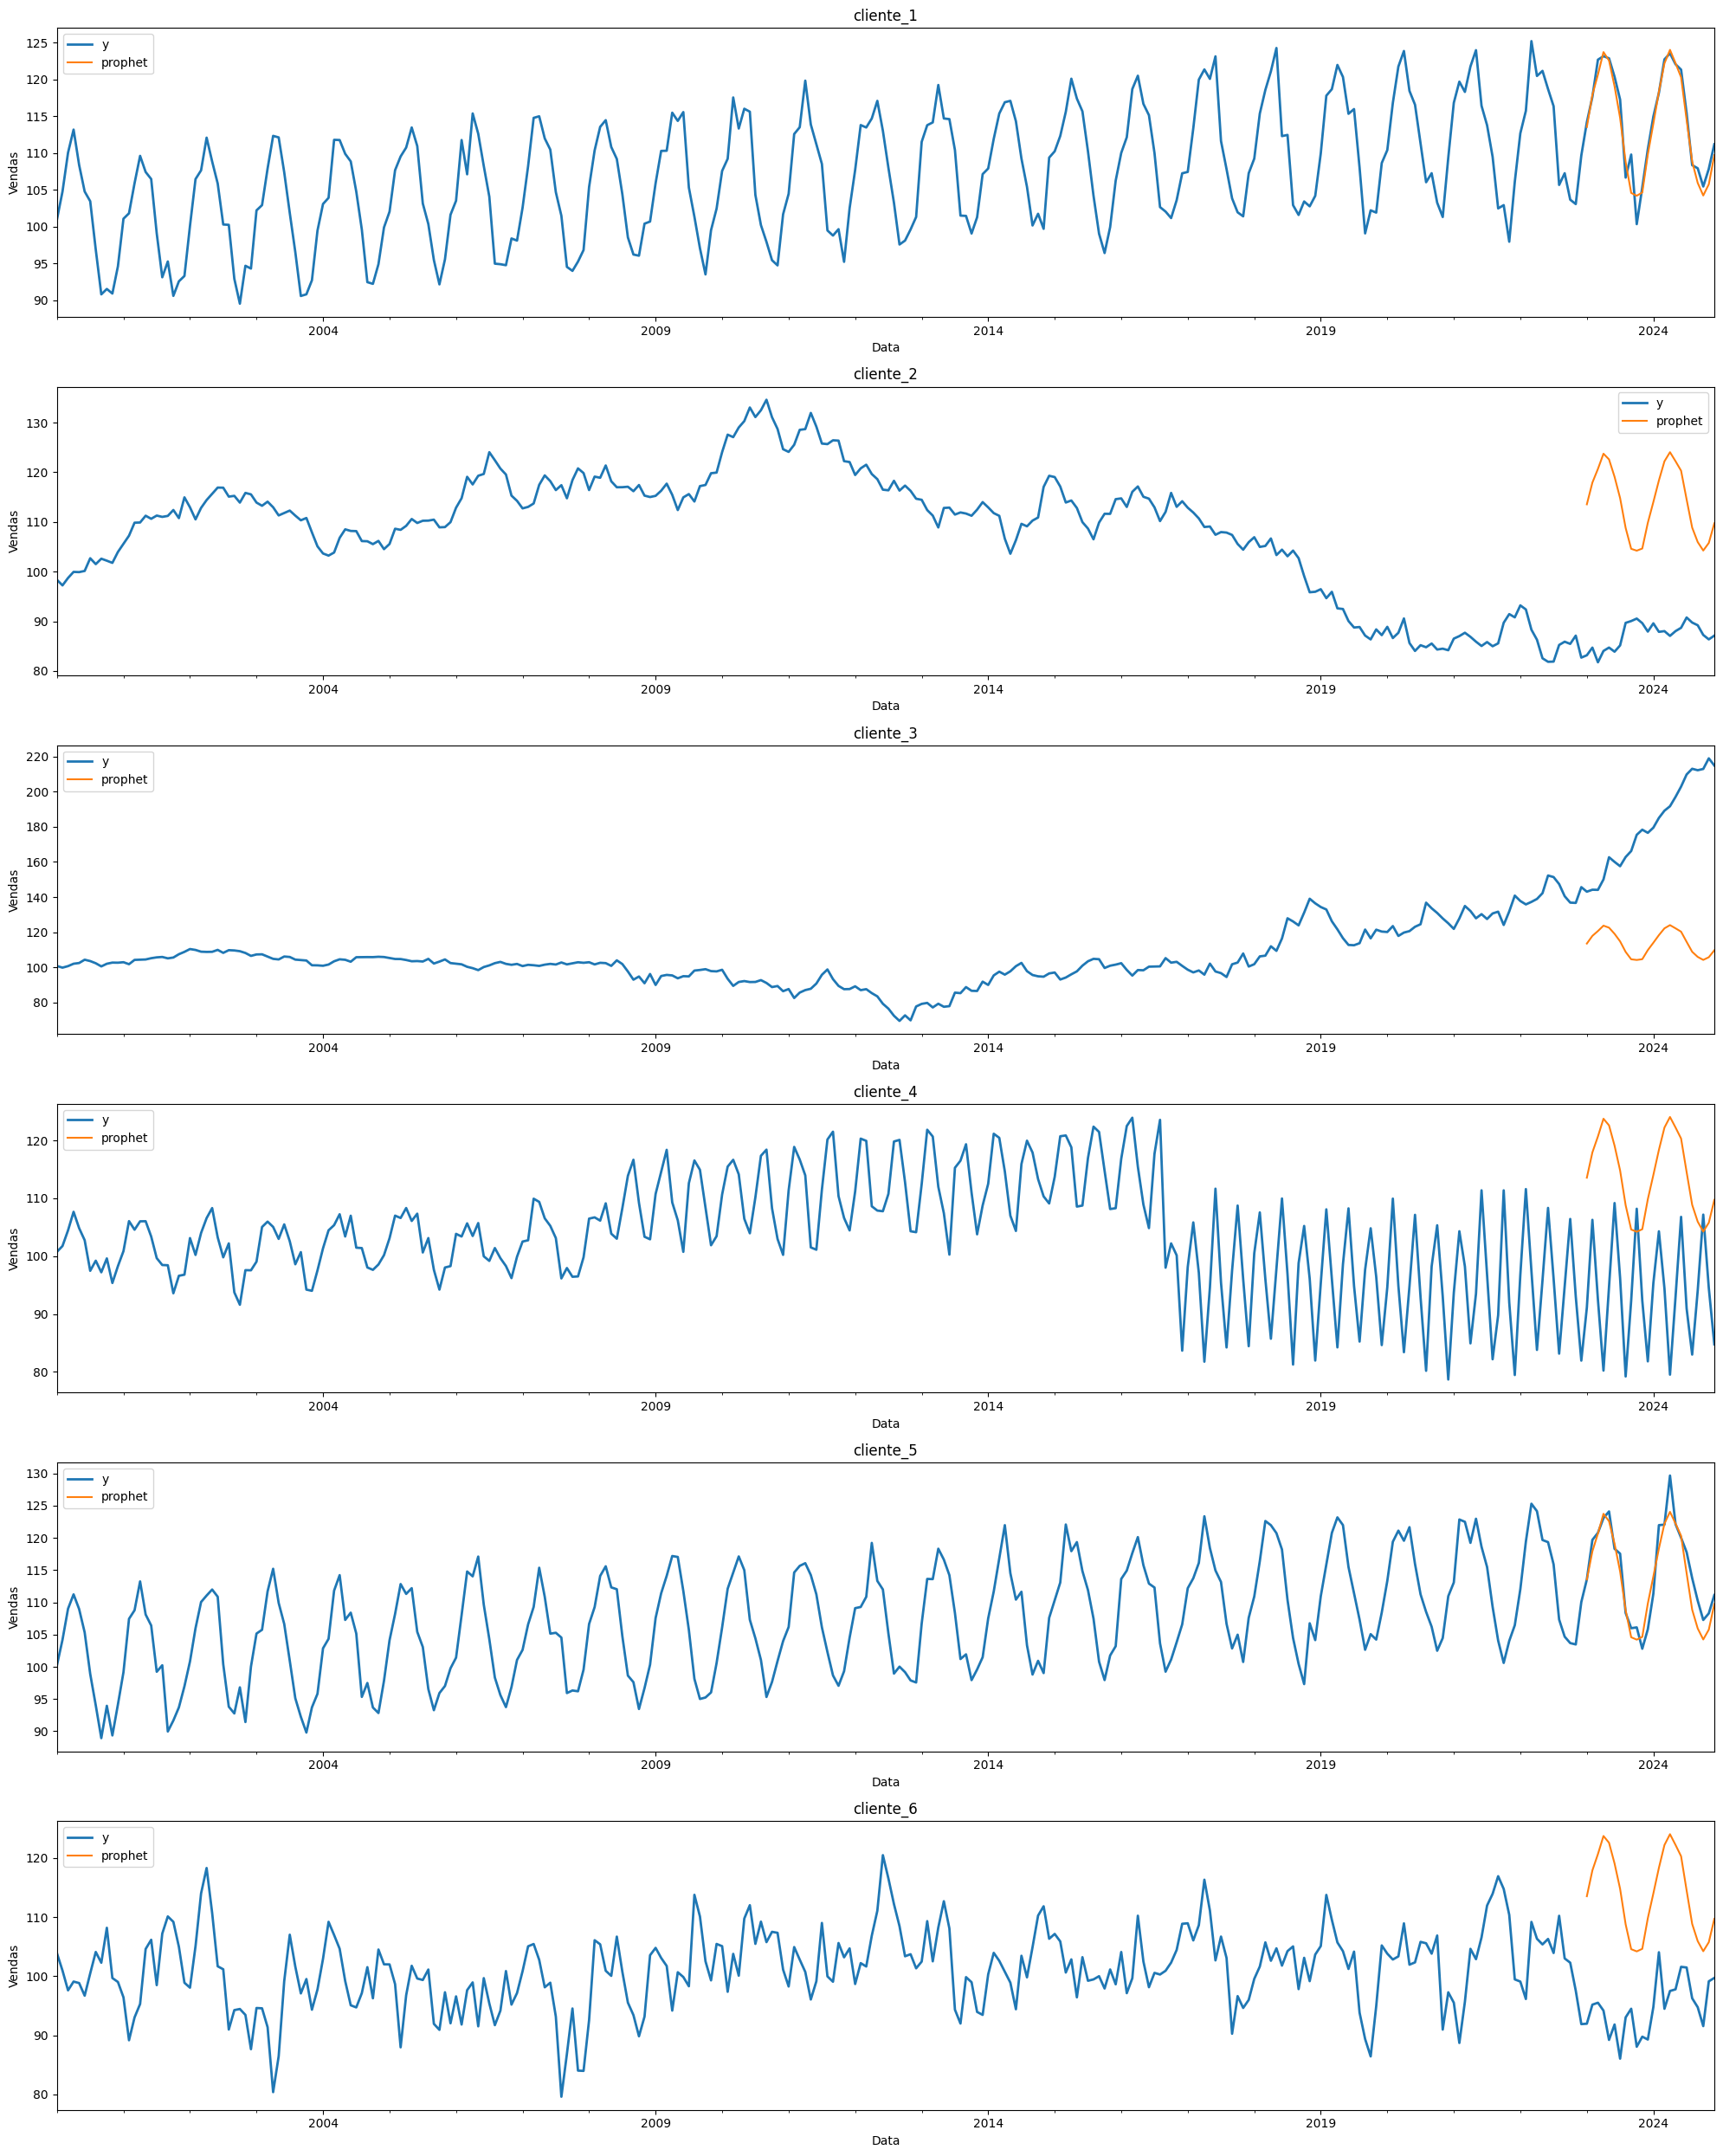

In [479]:
temp_df = pd.concat([df_train, df_test], axis=0)

fig, ax = plt.subplots(6 , 1, figsize=(20, 25))
for i, cl in enumerate(df_train.cliente_id.unique()):
    temp_df.loc[temp_df['cliente_id'] == cl].plot(x='ds', y='y', ax=ax[i], label='y', title=cl, linewidth=2)
    df_final.loc[df_final['cliente_id'] == cl].plot(x='ds', y='yhat', ax=ax[i], label='prophet')
    ax[i].set_xlabel('Data')
    ax[i].set_ylabel('Vendas')
    fig.tight_layout()

In [494]:
df_cl2 = df[df.cliente_id == 'cliente_2']
df2 = df_cl2.copy()
df2 = df2[['data', 'valor']]
df_train = df2[df2.data <= '2022-12-31'].set_index('data')
df_test = df2[df2.data > '2022-12-31'].set_index('data')

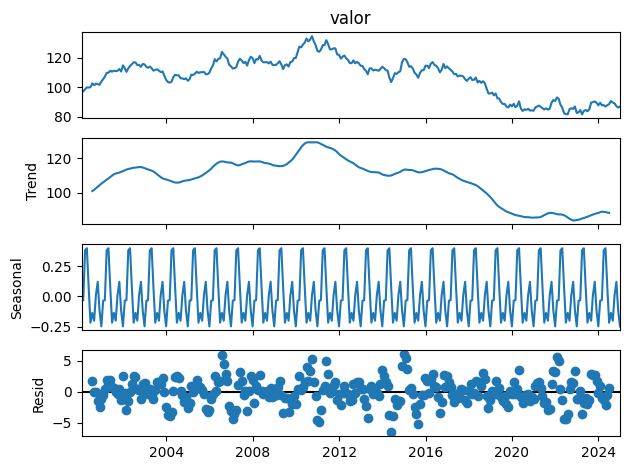

In [500]:
from statsmodels.tsa.seasonal import seasonal_decompose
res = seasonal_decompose(df_cl2.set_index('data')['valor'])
res.plot();

In [ ]:
from pmdarima import auto_arima

model = auto_arima(
    df_train,
    start_p=1, 
    start_q=1,
    max_p=5, 
    max_q=5, 
    max_d=2,
    seasonal=True,
    start_P=0, 
    start_Q=0,
    max_P=2, 
    max_Q=2, 
    max_D=1,
    m=12,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1152.695, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1150.220, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1151.504, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1151.520, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1148.455, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1150.633, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=1150.622, Time=0.03 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=1152.617, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1150.736, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1150.776, Time=0.01 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 0.312 seconds


In [565]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df_train, order=(0,1,0), seasonal_order=(0, 0, 0, 12), freq='M')
res = model.fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  valor   No. Observations:                  276
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -573.228
Date:                Qui, 13 Nov 2025   AIC                           1148.455
Time:                        21:29:22   BIC                           1152.072
Sample:                    01-31-2000   HQIC                          1149.907
                         - 12-31-2022                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         3.7850      0.336     11.258      0.000       3.126       4.444
===================================================================================
Ljung-Box (L1) (Q):                   1.47   Jarque-Bera (JB):                 0.90
Prob(Q):                              0.23   Prob(JB):                         0.64
Heteroskedasticity (H):               1.31   Skew:                             0.12
Prob(H) (two-sided):                  0.20   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [566]:
# preds = res.forecast(steps=24) -> isso funciona, mas não é possível setar o intervalo de confiança
previsao = res.get_forecast(steps=24)
intervalo_confianca = previsao.conf_int(alpha=0.1)
previsao_media = previsao.predicted_mean

df_test['yhat'] = previsao_media
wmape_ = wmape(df_test['valor'].values, df_test['yhat'].values)
print(f'WMAPE: {wmape_:.2%}')

from sklearn.metrics import mean_absolute_percentage_error
print(mean_absolute_percentage_error(df_test['valor'].values, df_test['yhat'].values) * 100)

WMAPE: 5.36%
5.286044990455649


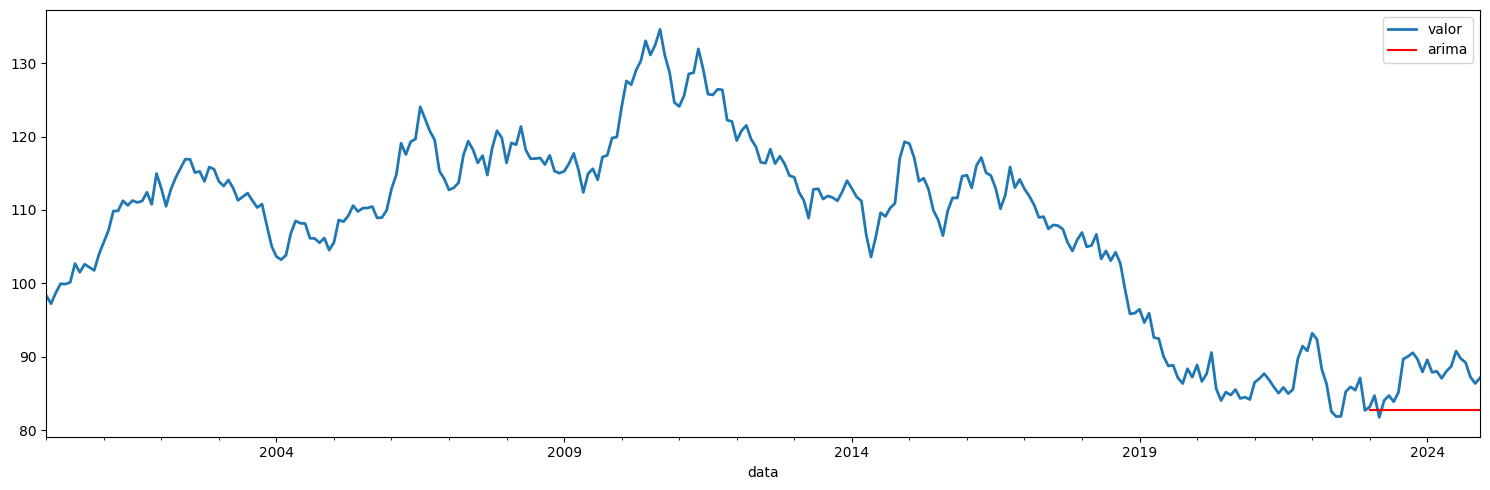

In [567]:
temp_df = pd.concat([df_train, df_test], axis=0)
temp_df.reset_index(inplace=True)

plt.figure(figsize=(15, 5))
ax = plt.gca()
temp_df.plot(x='data', y='valor', label='valor', linewidth=2, ax=ax)
temp_df.plot(x='data', y='yhat', label='arima', color='red', ax=ax)
plt.tight_layout()
plt.show()